# Logistic Regression – Weather Activity Suitability (nowcast)
**Target:** `Suitability` = 1 if `Summary == 'Clear'` (suitable for outdoor activity), else 0 (imbalanced: ~11% suitable).

> **Note on the target (for the review):** "suitable" is defined strictly as a `Clear` sky, so *Partly Cloudy* hours count as "not suitable". The weather columns are measured in the **same hour** as the label, so this is a *nowcast* of the sky condition from current + past readings, not a forecast of future weather.

> **Validation design:** the data is an hourly time series, so we use a **chronological** 80/20 split (first 80% of the time line = train, last 20% = test) and `TimeSeriesSplit` for cross-validation / tuning. Nothing is shuffled, so no future hour can leak into training. Model selection uses a **nested** CV for the tuned models (M6/M8), so the tuning step is not scored on the same folds it was chosen on. The test set was held out from model selection and tuning and was used only for final performance reporting (test results of the other varieties are printed for information, but no decision is based on them).

**Plan (model varieties):**
| # | Variety | Pre-processing | Imbalance handling | Tuning |
|---|---|---|---|---|
| M1 | Baseline LR | scaled raw features | none | none |
| M2 | LR + class weight | scaled raw features | `class_weight='balanced'` | none |
| M3 | LR + SMOTENC | scaled raw features | SMOTENC | none |
| M4 | LR + SMOTENC + engineered feature representation | cyclic hour/month/wind direction, pressure fix | SMOTENC | none |
| M5 | LR + SMOTENC + splines + interactions | M4 + spline + degree-3 interactions | SMOTENC | none |
| M6 | M5 tuned | same as M5 | SMOTENC (inside CV) | GridSearchCV (TimeSeriesSplit), scored with nested CV |
| M7 | M6 + decision threshold tuning | same | SMOTENC | threshold from out-of-fold predictions |
| M8 | M5 + lag/rolling features + current-to-past change features | lags, changes, rolling mean/std | SMOTENC (inside CV) | GridSearchCV (TimeSeriesSplit), scored with nested CV |
| M9 | M8 + threshold tuning | same | SMOTENC | threshold from out-of-fold predictions |

In [1]:
# !pip install imbalanced-learn   # (already available in Colab)
import warnings; warnings.filterwarnings('ignore', category=FutureWarning)   # NOTE: ConvergenceWarning is NOT hidden on purpose
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# ---- data path ----
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = "/content/drive/MyDrive/AI & ML Project /weatherHistory.csv"
except ImportError:
    DATA_PATH = "weatherHistory.csv"

df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


## 1. Cleaning & target

In [2]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [3]:
duplicates = df[df.duplicated()]
duplicates.shape

(24, 12)

In [4]:
# Only drop exact duplicates here.
# 'Precip Type' has ~500 NaN: they are forward-filled AFTER the data is sorted by time (section 2),
# because the raw file is not in time order and ffill on an unsorted file copies values from unrelated hours.
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)
df.isnull().sum()

Shape after dropping duplicates: (96429, 12)


,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [5]:
df['Precip Type'].value_counts(dropna=False)

,count
Precip Type,
rain,85200
snow,10712
NaN,517


In [6]:
df['Summary'].value_counts()

,count
Summary,
Partly Cloudy,31726
Mostly Cloudy,28094
Overcast,16597
Clear,10873
Foggy,7148
Breezy and Overcast,528
Breezy and Mostly Cloudy,516
Breezy and Partly Cloudy,386
Dry and Partly Cloudy,86


In [7]:
df['Suitability'] = (df['Summary'] == 'Clear').astype(int)

print(df.shape)
print(df['Suitability'].value_counts())
print((df['Suitability'].value_counts(normalize=True)*100).round(1))

(96429, 13)
Suitability
0    85556
1    10873
Name: count, dtype: int64
Suitability
0    88.7
1    11.3
Name: proportion, dtype: float64


## 2. Feature creation

In [8]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
# Hourly time series -> sort in time FIRST, then everything else (ffill, lags, split) is in true time order
df = df.sort_values('Formatted Date', kind='stable').reset_index(drop=True)

# Missing Precip Type values are forward-filled using the MOST RECENT KNOWN previous value.
# ASSUMPTION: that last known type is still valid during the gap. A gap can be longer than one hour (see the longest gap below).
# Supporting evidence (computed on the known values before filling):
_p = df['Precip Type']; _ok = _p.notna() & _p.shift(1).notna()
_na = _p.isna(); _longest_gap = int(_na.groupby((~_na).cumsum()).sum().max())
print("Missing Precip Type: %d rows (%.2f%% of the data) | longest run of consecutive missing hours: %d" % (_na.sum(), 100 * _na.mean(), _longest_gap))
print("Precip Type is unchanged from the previous hour in %.2f%% of consecutive known hours (persistence)" % (100 * (_p[_ok] == _p.shift(1)[_ok]).mean()))
# Forward fill is valid now that the data is in time order (only past information is used, no future leakage)
df['Precip Type'] = df['Precip Type'].ffill()
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])   # only if the very first row was NaN
print("Missing Precip Type left:", df['Precip Type'].isnull().sum())

SPLIT_POS = int(len(df) * 0.8)          # chronological split point: rows [:SPLIT_POS] = train, rows [SPLIT_POS:] = test
df['Timestamp']   = df['Formatted Date']
df['Month']       = df['Formatted Date'].dt.month
df['Day']         = df['Formatted Date'].dt.day
df['Hour']        = df['Formatted Date'].dt.hour
df['Day_of_week'] = df['Formatted Date'].dt.dayofweek
# NOTE: 'Year' is deliberately NOT used as a feature: with a chronological split the test years are
# outside the training years, so a model cannot learn anything useful from it.

df['Temp_Difference'] = df['Temperature (C)'] - df['Apparent Temperature (C)']
df['Wind_Humidity']   = df['Wind Speed (km/h)'] * df['Humidity']

df = pd.get_dummies(df, columns=['Precip Type'], prefix='Precip', dtype=int)

# Loud Cover is constant (all 0) -> useless
df = df.drop(columns=['Formatted Date', 'Summary', 'Daily Summary', 'Loud Cover'])

df = df.rename(columns={
    'Temperature (C)': 'Temperature', 'Apparent Temperature (C)': 'Apparent_Temperature',
    'Wind Speed (km/h)': 'Wind_Speed', 'Wind Bearing (degrees)': 'Wind_Bearing',
    'Visibility (km)': 'Visibility', 'Pressure (millibars)': 'Pressure',
    'Precip_rain': 'Precip_Rain', 'Precip_snow': 'Precip_Snow'})
df.head()

Missing Precip Type: 517 rows (0.54% of the data) | longest run of consecutive missing hours: 98
Precip Type is unchanged from the previous hour in 98.29% of consecutive known hours (persistence)
Missing Precip Type left: 0


,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Pressure,Suitability,Timestamp,Month,Day,Hour,Day_of_week,Temp_Difference,Wind_Humidity,Precip_Rain,Precip_Snow
0,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,1016.66,0,2005-12-31 23:00:00+00:00,12,31,23,5,4.627778,15.231727,1,0
1,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,1016.15,0,2006-01-01 00:00:00+00:00,1,1,0,6,4.400000,14.122920,1,0
2,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,1015.87,0,2006-01-01 01:00:00+00:00,1,1,1,6,4.822222,16.608116,1,0
3,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,1015.56,0,2006-01-01 02:00:00+00:00,1,1,2,6,3.905556,11.881800,1,0
4,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,1014.98,0,2006-01-01 03:00:00+00:00,1,1,3,6,3.927778,11.990636,1,0


## 3. Why plain Logistic Regression struggles here
Suitability is **non-linear** in hour, month and visibility (a straight line can't capture it), and `Pressure = 0` is a bad/missing reading. We check this quickly.

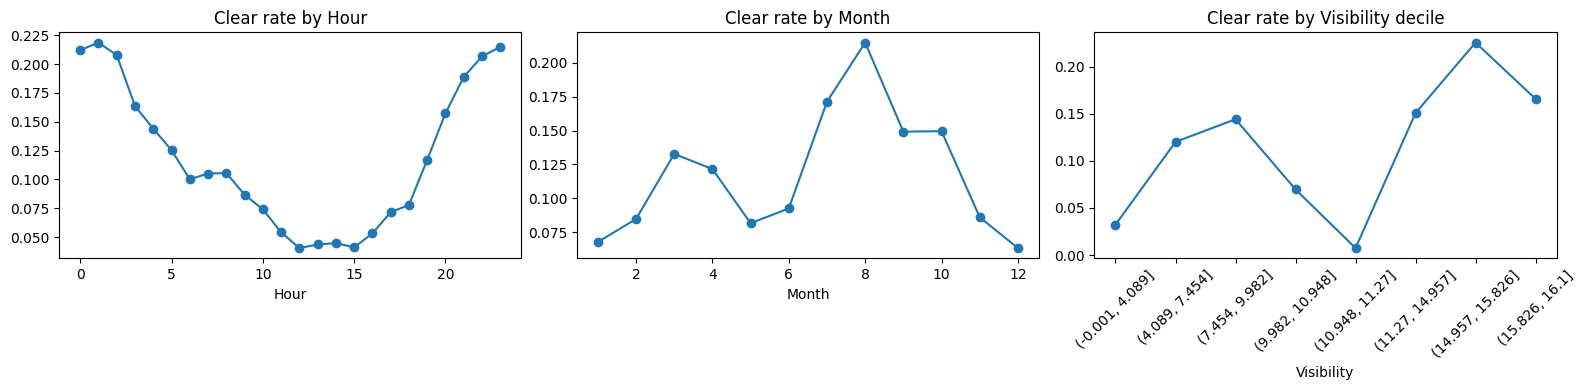

Rows with Pressure == 0: 1288


In [9]:
tr = df.iloc[:SPLIT_POS]          # EDA on the TRAIN part only
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
tr.groupby('Hour').Suitability.mean().plot(ax=ax[0], marker='o', title='Clear rate by Hour')
tr.groupby('Month').Suitability.mean().plot(ax=ax[1], marker='o', title='Clear rate by Month')
tr.groupby(pd.qcut(tr['Visibility'], 10, duplicates='drop')).Suitability.mean().plot(ax=ax[2], marker='o', title='Clear rate by Visibility decile')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print("Rows with Pressure == 0:", (df['Pressure'] == 0).sum())

## 4. Engineered features & Scaling Check

In [10]:
# Cyclic encoding: hour 23 and hour 0 are neighbours, December and January are neighbours
df['Hour_sin']  = np.sin(2*np.pi*df['Hour']/24);  df['Hour_cos']  = np.cos(2*np.pi*df['Hour']/24)
df['Month_sin'] = np.sin(2*np.pi*df['Month']/12); df['Month_cos'] = np.cos(2*np.pi*df['Month']/12)
# Wind_Bearing is a CIRCULAR variable (0-360 degrees): 359 and 0 are almost the same direction, but as a raw number they look far apart
df['Wind_Bearing_sin'] = np.sin(2*np.pi*df['Wind_Bearing']/360); df['Wind_Bearing_cos'] = np.cos(2*np.pi*df['Wind_Bearing']/360)

# ASSUMPTION: Pressure == 0 is a faulty / missing reading (0 millibars is physically impossible at the earth's surface,
# normal values are ~950-1050 mb). This is our assumption: the dataset documentation does not state it.
# -> flag it with Pressure_Missing and replace it with the median of the training period.
df['Pressure_Missing'] = (df['Pressure'] == 0).astype(int)
_nz = df.loc[df['Pressure'] > 0, 'Pressure']
print("Pressure == 0 rows:", int(df['Pressure_Missing'].sum()), "| non-zero readings range: %.1f - %.1f mb" % (_nz.min(), _nz.max()))
df['Pressure'] = df['Pressure'].replace(0, np.nan)
pressure_median = df['Pressure'].iloc[:SPLIT_POS].median()   # median of the TRAIN period only (= first 80% of time)
df['Pressure'] = df['Pressure'].fillna(pressure_median)


df[['Hour','Hour_sin','Hour_cos','Month','Month_sin','Month_cos','Wind_Bearing','Wind_Bearing_sin','Wind_Bearing_cos','Pressure','Pressure_Missing']].head()


Pressure == 0 rows: 1288 | non-zero readings range: 973.8 - 1046.4 mb


,Hour,Hour_sin,Hour_cos,Month,Month_sin,Month_cos,Wind_Bearing,Wind_Bearing_sin,Wind_Bearing_cos,Pressure,Pressure_Missing
0,23,-0.258819,0.965926,12,-2.449294e-16,1.000000,140.0,0.642788,-0.766044,1016.66,0
1,0,0.000000,1.000000,1,5.000000e-01,0.866025,139.0,0.656059,-0.754710,1016.15,0
2,1,0.258819,0.965926,1,5.000000e-01,0.866025,140.0,0.642788,-0.766044,1015.87,0
3,2,0.500000,0.866025,1,5.000000e-01,0.866025,140.0,0.642788,-0.766044,1015.56,0
4,3,0.707107,0.707107,1,5.000000e-01,0.866025,134.0,0.719340,-0.694658,1014.98,0


In [11]:
from sklearn.preprocessing import StandardScaler

# Columns used by the raw-feature models (scaling itself happens INSIDE each pipeline, fitted on TRAIN only)
num_cols = ['Temperature', 'Apparent_Temperature', 'Temp_Difference', 'Wind_Humidity',
            'Humidity', 'Wind_Speed', 'Wind_Bearing', 'Visibility', 'Pressure',
            'Month', 'Day', 'Hour', 'Day_of_week']

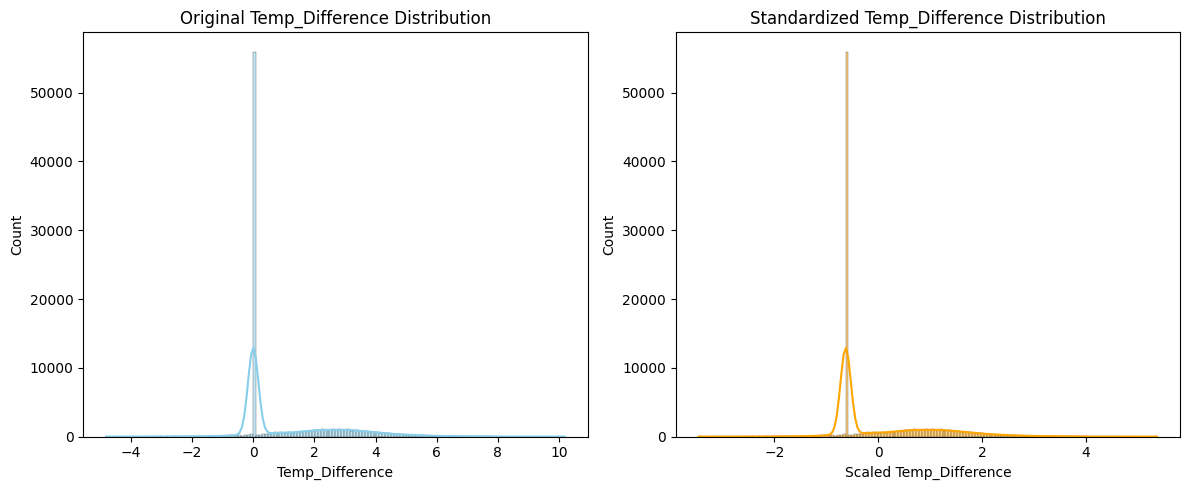

In [12]:
# Visual check of scaling on one feature (temporary scaler, only for the plot)
vis_scaler = StandardScaler().fit(df[num_cols].iloc[:SPLIT_POS])
df_scaled = pd.DataFrame(vis_scaler.transform(df[num_cols]), columns=num_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Temp_Difference'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Temp_Difference Distribution')
axes[0].set_xlabel('Temp_Difference')

sns.histplot(df_scaled['Temp_Difference'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Standardized Temp_Difference Distribution')
axes[1].set_xlabel('Scaled Temp_Difference')

plt.tight_layout()
plt.show()

## 5. Train / test split (chronological 80/20) – no scaling or oversampling before this

In [13]:
precip = ['Precip_Rain', 'Precip_Snow']

# Feature set A (original features) for M1-M3 (the baseline keeps the RAW Wind_Bearing; the engineered sets below use sin/cos)
raw_num  = ['Temperature','Apparent_Temperature','Temp_Difference','Wind_Humidity','Humidity','Wind_Speed',
            'Wind_Bearing','Visibility','Pressure','Month','Day','Hour','Day_of_week']
# Feature set B (engineered) for M4-M7
spline_cols = ['Temperature','Humidity','Wind_Speed','Visibility','Pressure','Temp_Difference']
cont_lin    = ['Hour_sin','Hour_cos','Month_sin','Month_cos','Wind_Bearing_sin','Wind_Bearing_cos']   # cyclic encodings (hour, month, wind direction)
bin_cols    = ['Pressure_Missing'] + precip
cont_eng    = spline_cols + cont_lin

y = df['Suitability']
X_raw = df[raw_num + precip]
X_eng = df[cont_eng + bin_cols]

# CHRONOLOGICAL split: first 80% of the time line = train (minus the 24 warm-up rows), last 20% = test (same split for every model M1-M9)
LAG_WARMUP = 24                         # warm-up: the first 24 rows are excluded so that all lag/rolling features (incl. the 24-hour rolling stats) have complete history (M8/M9)
idx_train = df.index[LAG_WARMUP:SPLIT_POS]   # ... and are excluded from training/CV of ALL models, so every model sees the same rows and no artificial fill is needed
idx_test  = df.index[SPLIT_POS:]
y_train, y_test   = y.loc[idx_train], y.loc[idx_test]
Xr_train, Xr_test = X_raw.loc[idx_train], X_raw.loc[idx_test]
Xe_train, Xe_test = X_eng.loc[idx_train], X_eng.loc[idx_test]

print("Train:", len(y_train), "| Test:", len(y_test))
print("Train period:", df.loc[idx_train, "Timestamp"].min(), "->", df.loc[idx_train, "Timestamp"].max())
print("Test  period:", df.loc[idx_test,  "Timestamp"].min(), "->", df.loc[idx_test,  "Timestamp"].max())
assert df.loc[idx_train, "Timestamp"].max() < df.loc[idx_test, "Timestamp"].min(), "train/test overlap in time!"
print("Clear rate  train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))

Train: 77119 | Test: 19286
Train period: 2006-01-01 23:00:00+00:00 -> 2014-10-20 08:00:00+00:00
Test  period: 2014-10-20 09:00:00+00:00 -> 2016-12-31 22:00:00+00:00
Clear rate  train: 0.119 | test: 0.088


## 6. Evaluation helper (metrics + confusion matrix)

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

results, cms = [], {}

def evaluate(name, model, X_te, thr=0.5, show=True):
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= thr).astype(int)
    results[:] = [r for r in results if r['Model'] != name]   # re-running a model cell replaces its old row (no duplicates)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    results.append({'Model': name, 'Threshold': round(thr, 3),
                    'Accuracy': accuracy_score(y_test, pred),
                    'Precision': precision_score(y_test, pred),
                    'Recall': recall_score(y_test, pred),
                    'F1': f1_score(y_test, pred),
                    'ROC_AUC': roc_auc_score(y_test, prob),
                    'PR_AUC': average_precision_score(y_test, prob),
                    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp})
    cms[name] = cm
    if show:
        print(name, '->', {k: round(v, 3) for k, v in results[-1].items() if k in
              ['Accuracy','Precision','Recall','F1','ROC_AUC','PR_AUC']})
        ConfusionMatrixDisplay(cm, display_labels=['Not Clear','Clear']).plot(cmap='Blues', values_format='d')
        plt.title(name); plt.show()

## 7. M1 – M3: original features (baseline, class weight, SMOTENC)

M1 Baseline LR -> {'Accuracy': 0.912, 'Precision': 0.474, 'Recall': 0.038, 'F1': 0.07, 'ROC_AUC': np.float64(0.602), 'PR_AUC': np.float64(0.171)}


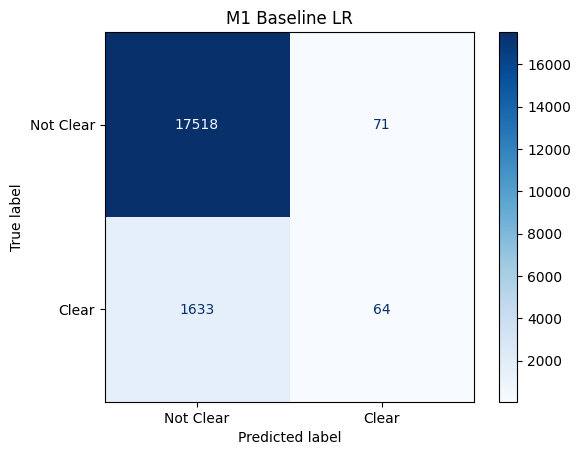

M2 LR + class_weight -> {'Accuracy': 0.559, 'Precision': 0.114, 'Recall': 0.591, 'F1': 0.191, 'ROC_AUC': np.float64(0.604), 'PR_AUC': np.float64(0.168)}


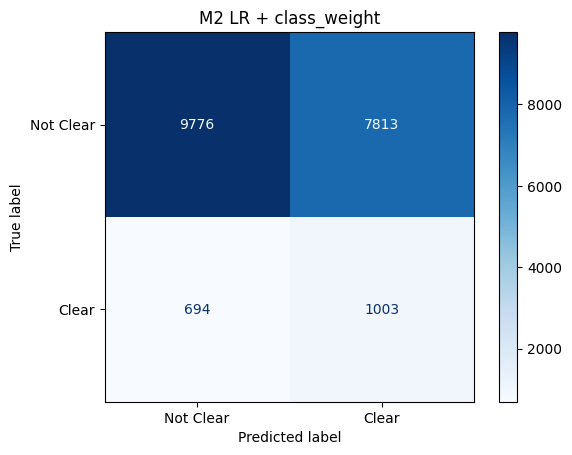

M3 LR + SMOTENC -> {'Accuracy': 0.562, 'Precision': 0.114, 'Recall': 0.586, 'F1': 0.191, 'ROC_AUC': np.float64(0.604), 'PR_AUC': np.float64(0.167)}


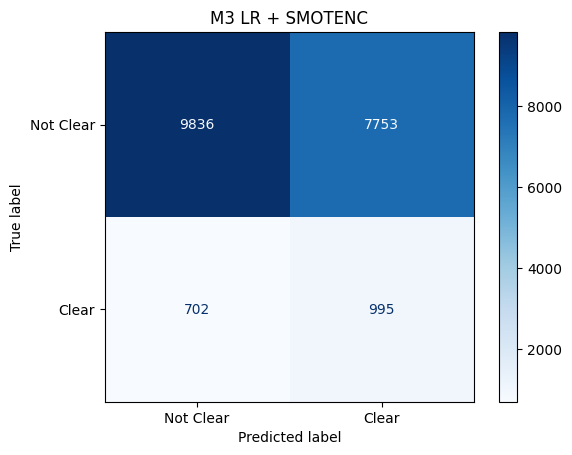

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

def make_smote(n_cont, n_bin):
    """SMOTENC for the pipelines. After the ColumnTransformer the n_bin binary columns (Precip_*, Pressure_Missing) are the LAST columns;
    SMOTENC treats them as categorical, so synthetic samples keep valid 0/1 values (plain SMOTE would create e.g. Precip_Rain = 0.37)."""
    return SMOTENC(categorical_features=list(range(n_cont, n_cont + n_bin)), random_state=42)

# scale the continuous columns, pass the binary Precip columns through unchanged
def raw_prep():
    return ColumnTransformer([('scale', StandardScaler(), raw_num)], remainder='passthrough')

# M1 baseline
m1 = Pipeline([('prep', raw_prep()), ('lr', LogisticRegression(max_iter=2000, random_state=42))]).fit(Xr_train, y_train)
evaluate('M1 Baseline LR', m1, Xr_test)

# M2 class_weight
m2 = Pipeline([('prep', raw_prep()), ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]).fit(Xr_train, y_train)
evaluate('M2 LR + class_weight', m2, Xr_test)

# M3 SMOTENC (TRAIN set only; no class_weight, so we don't balance twice)
m3 = ImbPipeline([('prep', raw_prep()), ('smote', make_smote(len(raw_num), len(precip))),
                  ('lr', LogisticRegression(max_iter=2000, random_state=42))]).fit(Xr_train, y_train)
evaluate('M3 LR + SMOTENC', m3, Xr_test)

### 7b. Is oversampling worth it? class_weight vs plain SMOTE vs SMOTENC
Plain SMOTE interpolates *every* column, so the binary columns (`Precip_Rain`, `Precip_Snow`) get invalid fractional values (e.g. `0.37`) in the synthetic rows. **SMOTENC** treats them as categorical and keeps valid 0/1 values, so SMOTENC is used for all oversampled models (M3–M9). This cell checks (1) how many synthetic rows get invalid values with plain SMOTE and (2) whether oversampling brings any benefit over `class_weight='balanced'` (quick time-series CV on the training rows, raw features, later folds only; the test set is not used).

In [16]:
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit

# (1) invalid values created by plain SMOTE in the binary columns (fit on TRAIN only)
_Xp = raw_prep().fit_transform(Xr_train)
_n0 = len(_Xp)
_Xs, _ = SMOTE(random_state=42).fit_resample(_Xp, y_train)
_Xn, _ = make_smote(len(raw_num), len(precip)).fit_resample(_Xp, y_train)
_bad = lambda X_: (np.abs(X_[_n0:, -len(precip):] - np.round(X_[_n0:, -len(precip):])) > 1e-9).any(axis=1).mean()
print('Synthetic rows with a fractional (invalid) binary value: plain SMOTE %.1f%% | SMOTENC %.1f%%' % (100*_bad(_Xs), 100*_bad(_Xn)))

# (2) does oversampling help? (time-series CV, later folds only, threshold 0.5)
_cv = TimeSeriesSplit(n_splits=3)
_variants = {
    'class_weight (M2)': Pipeline([('prep', raw_prep()), ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]),
    'plain SMOTE':       ImbPipeline([('prep', raw_prep()), ('smote', SMOTE(random_state=42)), ('lr', LogisticRegression(max_iter=2000, random_state=42))]),
    'SMOTENC (M3)':      ImbPipeline([('prep', raw_prep()), ('smote', make_smote(len(raw_num), len(precip))), ('lr', LogisticRegression(max_iter=2000, random_state=42))]),
}
_rows = []
for _nm, _est in _variants.items():
    _f1, _ap = [], []
    for _a, _b in list(_cv.split(Xr_train))[1:]:
        _m = clone(_est).fit(Xr_train.iloc[_a], y_train.iloc[_a])
        _p = _m.predict_proba(Xr_train.iloc[_b])[:, 1]
        _f1.append(f1_score(y_train.iloc[_b], (_p >= 0.5).astype(int))); _ap.append(average_precision_score(y_train.iloc[_b], _p))
    _rows.append({'Imbalance handling': _nm, 'CV F1 (later folds)': np.mean(_f1), 'CV PR-AUC (later folds)': np.mean(_ap)})
display(pd.DataFrame(_rows).set_index('Imbalance handling').round(3))
print('If the three F1 values are close, oversampling gives no clear benefit over class_weight for Logistic Regression.')
print('SMOTENC is still used for M3-M9 because it never creates invalid binary values; class_weight (M2) is an equally valid, simpler alternative.')


Synthetic rows with a fractional (invalid) binary value: plain SMOTE 0.9% | SMOTENC 0.0%


,CV F1 (later folds),CV PR-AUC (later folds)
Imbalance handling,,
class_weight (M2),0.307,0.270
plain SMOTE,0.307,0.269
SMOTENC (M3),0.307,0.269


If the three F1 values are close, oversampling gives no clear benefit over class_weight for Logistic Regression.
SMOTENC is still used for M3-M9 because it never creates invalid binary values; class_weight (M2) is an equally valid, simpler alternative.


## 8. M4 – M5: engineered features + SMOTENC

M4 LR + SMOTENC + engineered -> {'Accuracy': 0.641, 'Precision': 0.164, 'Recall': 0.751, 'F1': 0.269, 'ROC_AUC': np.float64(0.766), 'PR_AUC': np.float64(0.259)}


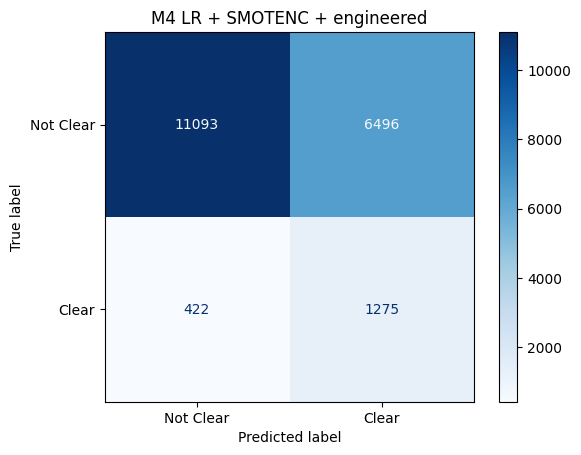

M5 LR + SMOTENC + spline + interactions -> {'Accuracy': 0.813, 'Precision': 0.248, 'Recall': 0.553, 'F1': 0.343, 'ROC_AUC': np.float64(0.779), 'PR_AUC': np.float64(0.326)}


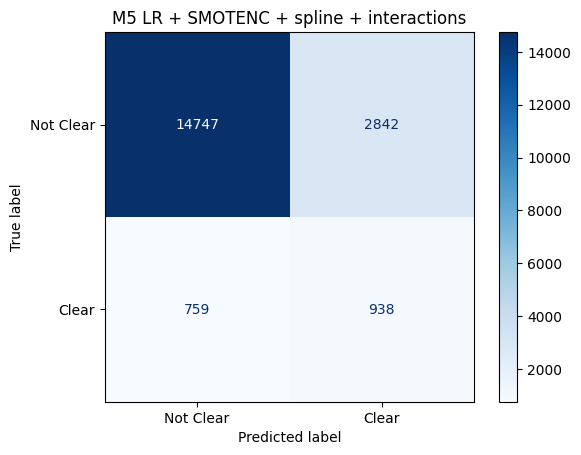

M5 LR iterations used: [369] (limit 1000 )


In [17]:
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures
from sklearn.pipeline import FeatureUnion

# Helper 1: scale continuous columns, keep binary columns unscaled
def eng_scale(cont_cols):
    return ColumnTransformer([('scale', StandardScaler(), cont_cols)], remainder='passthrough')

# Helper 2: non-linear expansion (splines on the first n_spline columns + polynomial interactions of ALL columns).
# It runs AFTER SMOTENC, so synthetic samples are made in the real feature space and then expanded consistently.
def expand_steps(n_spline, poly_degree):
    return [('fu', FeatureUnion([
                ('spline', ColumnTransformer([('sp', SplineTransformer(n_knots=6, degree=3), list(range(n_spline)))])),
                ('inter',  PolynomialFeatures(poly_degree, include_bias=False))])),
            ('sc2', StandardScaler())]

LR_ITER = 1000      # large enough for the expanded models (ConvergenceWarning is visible, not hidden)

# M4: cyclic hour/month + pressure fix, linear model
m4 = ImbPipeline([('prep', eng_scale(cont_eng)),
                  ('smote', make_smote(len(cont_eng), len(bin_cols))),
                  ('lr', LogisticRegression(max_iter=2000, random_state=42))]).fit(Xe_train, y_train)
evaluate('M4 LR + SMOTENC + engineered', m4, Xe_test)

# M5: add splines (non-linear shape per feature) + polynomial interactions (degree 3)
m5 = ImbPipeline([('prep', eng_scale(cont_eng)),
                  ('smote', make_smote(len(cont_eng), len(bin_cols)))]
                 + expand_steps(len(spline_cols), 3)
                 + [('lr', LogisticRegression(C=0.1, max_iter=LR_ITER, random_state=42))]).fit(Xe_train, y_train)
evaluate('M5 LR + SMOTENC + spline + interactions', m5, Xe_test)
print("M5 LR iterations used:", m5.named_steps['lr'].n_iter_, "(limit", LR_ITER, ")")

## 9. M6 – Hyperparameter tuning (GridSearchCV)
SMOTENC is **inside** the pipeline, so in each CV fold it only touches the training part (no leakage into validation folds).
Folds are made with **`TimeSeriesSplit`**: every validation fold lies *after* its training fold in time.
Scoring = `average_precision` (PR-AUC) – threshold-independent and suited to imbalanced data.
The grid is extended to `C = 0.001` because the best value of the first search was at the edge of the grid.

**Tuning data:** `TUNE_FRAC = 1.0`, so the full chronological training set was used for hyperparameter tuning. This applies to the grid searches of M6 and M8 and to the inner grid searches of the nested CV. (If `TUNE_FRAC` is lowered for speed, the report must say that only that fraction of the training rows was used.)

In [18]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.base import clone

pipe = ImbPipeline([('prep', eng_scale(cont_eng)),
                    ('smote', make_smote(len(cont_eng), len(bin_cols)))]
                   + expand_steps(len(spline_cols), 3)
                   + [('lr', LogisticRegression(max_iter=LR_ITER, random_state=42))])

param_grid = {'lr__C': [0.001, 0.01, 0.1], 'smote__k_neighbors': [3, 5]}
cv = TimeSeriesSplit(n_splits=3)          # used for tuning AND for the model-selection CV (section 10c)

# TUNE_FRAC = 1.0 -> the FULL chronological training set is used for the hyperparameter search (test set untouched).
# (A value < 1 would use a time-ordered random subsample of the training rows: faster, but it must then be reported as a limitation.
#  The nested CV in section 10c uses the same fraction.)
TUNE_FRAC = 1.0
Xe_sub = Xe_train.sample(frac=TUNE_FRAC, random_state=42).sort_index()
y_sub  = y_train.loc[Xe_sub.index]

grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='average_precision',
                    n_jobs=2, verbose=1, refit=False)
grid.fit(Xe_sub, y_sub)
print("Best params:", grid.best_params_)
print("Best CV PR-AUC (tuning data):", round(grid.best_score_, 4))

# refit ONCE on the full training set with the best parameters
m6 = clone(pipe).set_params(**grid.best_params_).fit(Xe_train, y_train)

pd.DataFrame(grid.cv_results_)[['param_lr__C','param_smote__k_neighbors','mean_test_score','std_test_score','rank_test_score']]

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'lr__C': 0.001, 'smote__k_neighbors': 3}
Best CV PR-AUC (tuning data): 0.3599


,param_lr__C,param_smote__k_neighbors,mean_test_score,std_test_score,rank_test_score
0,0.001,3,0.359902,0.025400,1
1,0.001,5,0.357391,0.027143,2
2,0.010,3,0.340176,0.027194,4
3,0.010,5,0.340386,0.026502,3
4,0.100,3,0.330059,0.029903,6
5,0.100,5,0.331095,0.026364,5


M6 Tuned (GridSearchCV) -> {'Accuracy': 0.729, 'Precision': 0.198, 'Recall': 0.681, 'F1': 0.307, 'ROC_AUC': np.float64(0.775), 'PR_AUC': np.float64(0.31)}


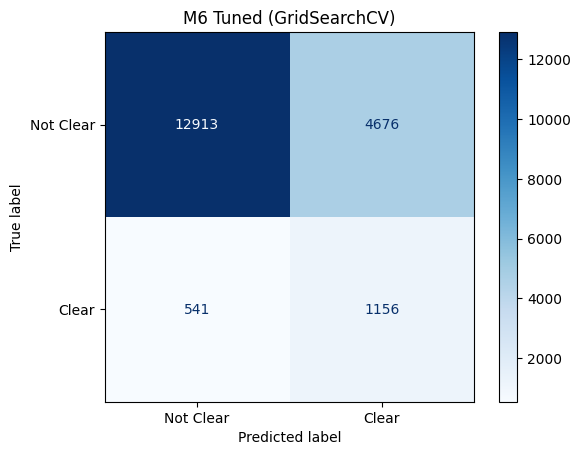

In [19]:
evaluate('M6 Tuned (GridSearchCV)', m6, Xe_test)


## 10. M7 – Decision-threshold tuning
The default threshold 0.5 is not optimal for imbalanced data. M7 (and M9) therefore use the threshold that maximises F1 on the **pooled out-of-fold predictions of a time-series CV on the training set**. For the final test evaluation, the final M6/M8 hyperparameters (best `C`, best SMOTE `k_neighbors`) are fixed, a `TimeSeriesSplit` CV with these fixed parameters produces out-of-fold probabilities on the training set, and the best-F1 threshold is taken from these pooled predictions; the final model is then refitted on the full training set and evaluated on the test set. The threshold is not selected using the test set.
Both thresholded models are created in section 10c (the thresholds are computed there, together with the cross-validation of all varieties).

## 10b. M8: add lag / rolling / change features
The data is hourly, and whether the sky is clear depends on how the weather has been *changing* (e.g. pressure rising, visibility improving). We add **lagged and rolling historical features** (shift/rolling over previous hours) together with **current-to-past change features** (`_chg1`, `_chg3` = current-hour value minus the lagged value). The target itself is never used. Using the current-hour weather measurement is allowed here because the task is a *nowcast* (the weather columns are measured in the same hour as the label); for a real *forecast* the change features would leak and would have to be removed. The first 24 rows are excluded as a warm-up period so that all lag/rolling features, including the 24-hour rolling statistics, have complete historical information. They are used only as history and are excluded from training/CV/test for all models (no artificial filling of lags). Then we tune again. M9 (= M8 + threshold) is created in section 10c.

In [20]:
lag_base = ['Visibility', 'Humidity', 'Temperature', 'Pressure', 'Wind_Speed']
d = df.copy()                       # df is in time order
lag_cols = []

for c in lag_base:
    s = d[c]
    # lag / rolling features use only PAST values. The first rows have incomplete history: they are NOT filled artificially; the first LAG_WARMUP = 24 rows
    # are simply excluded as a warm-up period (see idx_train), so every modelled row has complete history for all lag/rolling features, including the 24-hour rolling statistics (roll24 = shift(1) of a 24-hour window).
    # chg features compare the CURRENT-hour value with the past: fine for a nowcast, would be leakage for a forecast
    d[f'{c}_lag1']   = s.shift(1)
    d[f'{c}_lag3']   = s.shift(3)
    d[f'{c}_chg1']   = s - d[f'{c}_lag1']
    d[f'{c}_chg3']   = s - d[f'{c}_lag3']
    d[f'{c}_roll6']  = s.rolling(6,  min_periods=1).mean().shift(1)
    d[f'{c}_roll24'] = s.rolling(24, min_periods=1).mean().shift(1)
    d[f'{c}_std6']   = s.rolling(6,  min_periods=2).std().shift(1)
    lag_cols += [f'{c}_{t}' for t in ['lag1','lag3','chg1','chg3','roll6','roll24','std6']]

cont_lag  = spline_cols + lag_cols + cont_lin          # continuous (first 6 = spline columns)
lag_feats = cont_lag + bin_cols                        # binary columns at the end
Xl_train, Xl_test = d.loc[idx_train, lag_feats], d.loc[idx_test, lag_feats]
_used = idx_train.append(idx_test)
n_nan = int(d.loc[_used, lag_feats].isnull().sum().sum())
print("Number of features:", len(lag_feats), "| NaN in the rows used for modelling:", n_nan, "| NaN only in the", LAG_WARMUP, "warm-up rows:", int(d[lag_feats].isnull().sum().sum()) > 0)
assert n_nan == 0, "lag features contain NaN in modelling rows - increase LAG_WARMUP"

Number of features: 50 | NaN in the rows used for modelling: 0 | NaN only in the 24 warm-up rows: True


In [21]:
steps = d['Timestamp'].diff().dropna()
print("Sorted in time order:", d['Timestamp'].is_monotonic_increasing)
print("Backward jumps:", (steps < pd.Timedelta(0)).sum())
print(steps.value_counts().head(3))

Sorted in time order: True
Backward jumps: 0
Timestamp
0 days 01:00:00    96427
0 days 04:00:00        1
Name: count, dtype: int64


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'lr__C': 0.001, 'smote__k_neighbors': 3} | Best CV PR-AUC (tuning data): 0.4181
M8 Lag features + tuned -> {'Accuracy': 0.816, 'Precision': 0.267, 'Recall': 0.623, 'F1': 0.373, 'ROC_AUC': np.float64(0.797), 'PR_AUC': np.float64(0.349)}


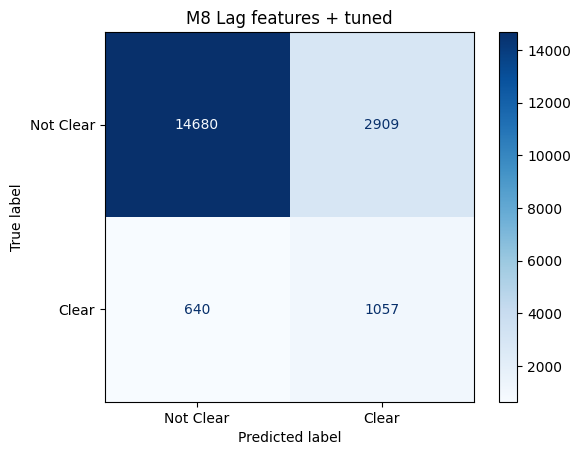

In [22]:
pipe_lag = ImbPipeline([('prep', eng_scale(cont_lag)),
                        ('smote', make_smote(len(cont_lag), len(bin_cols)))]
                       + expand_steps(len(spline_cols), 2)
                       + [('lr', LogisticRegression(max_iter=LR_ITER, random_state=42))])

# same tuning rows (TUNE_FRAC) as for M6
Xl_sub, yl_sub = Xl_train.loc[Xe_sub.index], y_train.loc[Xe_sub.index]

grid_lag = GridSearchCV(pipe_lag, param_grid, cv=cv, scoring='average_precision',
                        n_jobs=2, verbose=1, refit=False)
grid_lag.fit(Xl_sub, yl_sub)
print("Best params:", grid_lag.best_params_, "| Best CV PR-AUC (tuning data):", round(grid_lag.best_score_, 4))

m8 = clone(pipe_lag).set_params(**grid_lag.best_params_).fit(Xl_train, y_train)
evaluate('M8 Lag features + tuned', m8, Xl_test)

## 10c. Cross-validation of all varieties (model selection) – nested for the tuned models
Every variety (M1–M8) is evaluated with **3-fold `TimeSeriesSplit`** on the training set (SMOTENC inside each fold, validation always later in time than training).

**Nested CV for M6 / M8:** the hyperparameters of M6 and M8 (`C`, SMOTE `k_neighbors`) are chosen by a grid search. If the same CV folds were used both to choose the hyperparameters and to score the model, the CV F1 would be slightly optimistic. Therefore, in every *outer* fold the whole grid search is repeated **inside the outer training part only** (inner `TimeSeriesSplit`), the best parameters are refitted on that outer training part, and the model is scored on the outer validation part, which it has never seen. The CV F1 of M6/M8 therefore *includes the tuning step* and is an (almost) unbiased estimate. The final M6/M8 that are reported on the test set are still the ones tuned once on the whole training set (sections 9 and 10b).

**M7 / M9 (threshold models) – forward-only threshold:** in the CV score the threshold is chosen in a strictly forward-only way. For validation fold *i* the threshold is the best-F1 threshold of the pooled out-of-fold predictions of the **earlier** folds only (folds 1 … *i*-1); later folds are never used. Fold 1 has no earlier fold, so a forward-only threshold exists only for folds 2 … *k*. To compare all varieties fairly, **the CV scores of all nine varieties (`CV_F1`, `CV_Precision`, `CV_Recall`, …) are therefore computed on the same folds 2 … *k***; the column `CV_F1_all_folds` additionally shows the mean over all folds for M1–M8 (information only).

**Threshold used on the test set:** For the final test evaluation, the final M6/M8 hyperparameters (best `C`, best SMOTE `k_neighbors`) are fixed, a `TimeSeriesSplit` CV with these fixed parameters produces out-of-fold probabilities on the training set, and the best-F1 threshold is taken from these pooled predictions; the final model is then refitted on the full training set and evaluated on the test set. The threshold is not selected using the test set. (The CV *score* of M7/M9 below still uses the nested out-of-fold predictions with the forward-only threshold, because those are free of tuning bias.)

**M7 and M9 are treated as separate model configurations because decision-threshold selection is part of their modelling procedure.** Their CV F1 therefore includes the threshold-selection step (forward-only, from earlier folds), and comparing them directly with M1–M6/M8 (fixed threshold 0.5) in `idxmax()` is a comparison between complete modelling procedures, not between classifiers at the same threshold.

The final model is the one with the best CV F1. The test set was held out from model selection and tuning and was used only for final performance reporting (test results of the other varieties are printed for information, but no decision is based on them).

done: M1 Baseline LR 
done: M2 LR + class_weight 
done: M3 LR + SMOTENC 
done: M4 LR + SMOTENC + engineered 
done: M5 LR + SMOTENC + spline + interactions 
done: M6 Tuned (GridSearchCV) (nested CV)
done: M8 Lag features + tuned (nested CV)
done: fixed-parameter OOF run for M6 Tuned (GridSearchCV) {'lr__C': 0.001, 'smote__k_neighbors': 3}
done: fixed-parameter OOF run for M8 Lag features + tuned {'lr__C': 0.001, 'smote__k_neighbors': 3}


,Threshold,CV_F1,CV_F1_std,CV_Precision,CV_Recall,CV_PR_AUC,CV_ROC_AUC,CV_F1_all_folds
Model,,,,,,,,
M1 Baseline LR,0.500,0.043,0.014,0.497,0.023,0.270,0.752,0.038
M2 LR + class_weight,0.500,0.307,0.046,0.195,0.766,0.270,0.752,0.303
M3 LR + SMOTENC,0.500,0.307,0.047,0.195,0.763,0.269,0.753,0.303
M4 LR + SMOTENC + engineered,0.500,0.354,0.045,0.231,0.784,0.340,0.810,0.352
M5 LR + SMOTENC + spline + interactions,0.500,0.409,0.018,0.310,0.605,0.349,0.825,0.396
M6 Tuned (GridSearchCV),0.500,0.400,0.034,0.271,0.768,0.377,0.839,0.391
M7 Tuned + threshold,0.662,0.424,0.025,0.317,0.643,0.377,0.839,NaN
M8 Lag features + tuned,0.500,0.454,0.027,0.327,0.745,0.438,0.859,0.439
M9 Lag + tuned + threshold,0.659,0.479,0.015,0.407,0.584,0.438,0.859,NaN


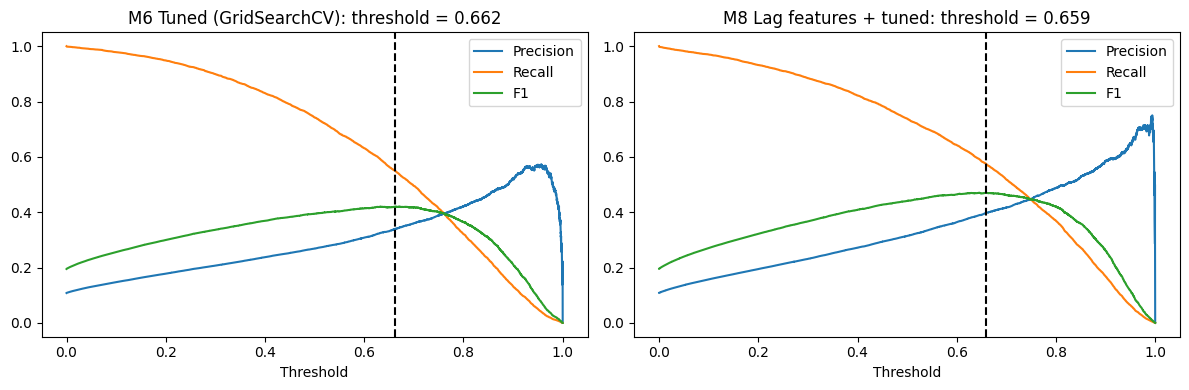

Final model chosen by CV F1: M9 Lag + tuned + threshold


In [23]:
# ===== Cross-validation of ALL varieties (model selection happens here, NOT on the test set) =====
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve

# name -> (unfitted copy of the pipeline, its TRAIN features). clone() keeps the hyperparameters, drops the fitted state.
cv_models = {
    'M1 Baseline LR':                          (clone(m1), Xr_train),
    'M2 LR + class_weight':                    (clone(m2), Xr_train),
    'M3 LR + SMOTENC':                           (clone(m3), Xr_train),
    'M4 LR + SMOTENC + engineered':              (clone(m4), Xe_train),
    'M5 LR + SMOTENC + spline + interactions':   (clone(m5), Xe_train),
    'M6 Tuned (GridSearchCV)':                 (clone(m6), Xe_train),
    'M8 Lag features + tuned':                 (clone(m8), Xl_train),
}

# M6 / M8 are scored with NESTED CV: the grid search is repeated inside every outer training fold
tuned_templates = {'M6 Tuned (GridSearchCV)': pipe, 'M8 Lag features + tuned': pipe_lag}
nested_choices = []

def fold_predict(name, est, Xtr, a, b, fold_no):
    Xa, ya = Xtr.iloc[a], y_train.iloc[a]
    if name in tuned_templates:
        Xs = Xa.sample(frac=TUNE_FRAC, random_state=42).sort_index()          # same subsample rule as the final search
        gs = GridSearchCV(tuned_templates[name], param_grid, cv=cv, scoring='average_precision',
                          n_jobs=2, refit=False)                              # inner TimeSeriesSplit, outer TRAIN part only
        gs.fit(Xs, y_train.loc[Xs.index])
        nested_choices.append({'Model': name, 'Outer fold': fold_no, **gs.best_params_,
                               'Inner CV PR-AUC': round(gs.best_score_, 4)})
        m = clone(tuned_templates[name]).set_params(**gs.best_params_).fit(Xa, ya)
    else:
        m = clone(est).fit(Xa, ya)                                            # SMOTENC (if any) only sees the training part
    return m.predict_proba(Xtr.iloc[b])[:, 1]

def best_f1_threshold(y_true, prob):
    prec, rec, thr = precision_recall_curve(y_true, prob)
    f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    i = np.argmax(f1s)
    return thr[i], f1s[i], prec[i], rec[i]

rows, fold_store = [], {}
for name, (est, Xtr) in cv_models.items():
    folds, fy, fp = [], [], []
    for fold_no, (a, b) in enumerate(cv.split(Xtr), 1):         # TimeSeriesSplit: validation fold is AFTER the training fold
        p = fold_predict(name, est, Xtr, a, b, fold_no)
        yb, pr = y_train.iloc[b], (p >= 0.5).astype(int)
        folds.append([f1_score(yb, pr), precision_score(yb, pr, zero_division=0), recall_score(yb, pr),
                      average_precision_score(yb, p), roc_auc_score(yb, p)])
        fy.append(yb.values); fp.append(p)                      # out-of-fold predictions (used for the thresholds)
    fold_store[name] = (fy, fp)
    f = np.array(folds)
    fc = f[1:]      # COMMON folds 2..k: the only folds where a forward-only threshold exists -> all varieties are scored on them
    rows.append({'Model': name, 'Threshold': 0.5, 'CV_F1': fc[:, 0].mean(), 'CV_F1_std': fc[:, 0].std(),
                 'CV_Precision': fc[:, 1].mean(), 'CV_Recall': fc[:, 2].mean(),
                 'CV_PR_AUC': fc[:, 3].mean(), 'CV_ROC_AUC': fc[:, 4].mean(),
                 'CV_F1_all_folds': f[:, 0].mean()})          # information only (not used for selection)
    print('done:', name, '(nested CV)' if name in tuned_templates else '')

# ---- OOF predictions with the FINAL, FIXED hyperparameters (used for the threshold that goes with the final M6/M8) ----
# The nested CV above picks different parameters in different outer folds, so its OOF predictions do not come from exactly the final model.
# Clean flow for the test threshold:  final M6/M8 parameters (best C, best SMOTE k)  ->  TimeSeriesSplit CV with these FIXED parameters
# ->  OOF probabilities  ->  best-F1 threshold  ->  (the final model m6/m8 was already refitted on the full training set)  ->  test.
fixed_cfg = {'M6 Tuned (GridSearchCV)': (pipe, Xe_train, grid.best_params_),
             'M8 Lag features + tuned': (pipe_lag, Xl_train, grid_lag.best_params_)}
fixed_oof = {}
for nm_, (tmpl_, Xtr_, bp_) in fixed_cfg.items():
    fy_, fp_ = [], []
    for a_, b_ in cv.split(Xtr_):
        m_ = clone(tmpl_).set_params(**bp_).fit(Xtr_.iloc[a_], y_train.iloc[a_])
        fy_.append(y_train.iloc[b_].values); fp_.append(m_.predict_proba(Xtr_.iloc[b_])[:, 1])
    fixed_oof[nm_] = (fy_, fp_)
    print('done: fixed-parameter OOF run for', nm_, bp_)

# M7 / M9 = M6 / M8 + threshold.
# CV score: FORWARD-ONLY threshold. For validation fold i the threshold is chosen from the pooled out-of-fold predictions of the
# EARLIER folds only (0..i-1); later (future) folds are never used. Fold 0 has no earlier fold, so M7/M9 are scored on folds 1..k-1,
# which are the same folds used for the CV scores of M1-M8 above (common folds).
base_rows = {r['Model']: r for r in rows}
def threshold_row(new_name, src):
    fy, fp = fold_store[src]; n = len(fy); f1l, pl, rl = [], [], []
    for i in range(1, n):
        y_o = np.concatenate(fy[:i])                    # earlier folds only
        p_o = np.concatenate(fp[:i])
        t_i = best_f1_threshold(y_o, p_o)[0]
        pr = (fp[i] >= t_i).astype(int)
        f1l.append(f1_score(fy[i], pr)); pl.append(precision_score(fy[i], pr, zero_division=0)); rl.append(recall_score(fy[i], pr))
    # threshold used on the TEST set: pooled OOF predictions of ALL training folds, produced by models with the FINAL FIXED hyperparameters
    # (same configuration as the final m6/m8 that is evaluated on the test set; the test set is never used)
    fy_f, fp_f = fixed_oof[src]
    thr_final = best_f1_threshold(np.concatenate(fy_f), np.concatenate(fp_f))[0]
    return {'Model': new_name, 'Threshold': thr_final, 'CV_F1': np.mean(f1l), 'CV_F1_std': np.std(f1l),
            'CV_Precision': np.mean(pl), 'CV_Recall': np.mean(rl),
            'CV_PR_AUC': base_rows[src]['CV_PR_AUC'], 'CV_ROC_AUC': base_rows[src]['CV_ROC_AUC'],
            'CV_F1_all_folds': np.nan}, thr_final

row7, thr_m7 = threshold_row('M7 Tuned + threshold', 'M6 Tuned (GridSearchCV)')
row9, thr_m9 = threshold_row('M9 Lag + tuned + threshold', 'M8 Lag features + tuned')
rows += [row7, row9]

cv_table = pd.DataFrame(rows).set_index('Model').sort_index()
display(cv_table.round(3))

# threshold curves (pooled out-of-fold predictions of the fixed-parameter CV = the ones the test threshold comes from)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a_, (nm, th_) in zip(ax, [('M6 Tuned (GridSearchCV)', thr_m7), ('M8 Lag features + tuned', thr_m9)]):
    fy, fp = fixed_oof[nm]
    pr_, rc_, tt_ = precision_recall_curve(np.concatenate(fy), np.concatenate(fp))
    f1_ = 2*pr_[:-1]*rc_[:-1] / (pr_[:-1] + rc_[:-1] + 1e-12)
    a_.plot(tt_, pr_[:-1], label='Precision'); a_.plot(tt_, rc_[:-1], label='Recall'); a_.plot(tt_, f1_, label='F1')
    a_.axvline(th_, color='k', ls='--'); a_.set_xlabel('Threshold'); a_.set_title(f'{nm}: threshold = {th_:.3f}'); a_.legend()
plt.tight_layout(); plt.show()

# ---- FINAL MODEL = best CV F1 on the common folds (test set NOT used for this decision) ----
final_name = cv_table['CV_F1'].idxmax()
print('Final model chosen by CV F1:', final_name)

final_map = {   # name -> (fitted model, TEST features, threshold)
    'M1 Baseline LR': (m1, Xr_test, 0.5), 'M2 LR + class_weight': (m2, Xr_test, 0.5), 'M3 LR + SMOTENC': (m3, Xr_test, 0.5),
    'M4 LR + SMOTENC + engineered': (m4, Xe_test, 0.5), 'M5 LR + SMOTENC + spline + interactions': (m5, Xe_test, 0.5),
    'M6 Tuned (GridSearchCV)': (m6, Xe_test, 0.5), 'M7 Tuned + threshold': (m6, Xe_test, thr_m7),
    'M8 Lag features + tuned': (m8, Xl_test, 0.5), 'M9 Lag + tuned + threshold': (m8, Xl_test, thr_m9)}
final_model, X_final_test, final_thr = final_map[final_name]
final_prob = final_model.predict_proba(X_final_test)[:, 1]
final_pred = (final_prob >= final_thr).astype(int)

# evaluate M7 / M9 on the test set with the pooled out-of-fold thresholds (reporting only)
for nm, mdl, Xt, th in [('M7 Tuned + threshold', m6, Xe_test, thr_m7),
                        ('M9 Lag + tuned + threshold', m8, Xl_test, thr_m9)]:
    evaluate(nm, mdl, Xt, thr=th, show=False)
results.sort(key=lambda r: r['Model'])      # keep M1..M9 order

## 10d. Parameter tuning summary – number and variety of models trained
Shows the grid-search results of both searches (M6, M8), the hyperparameters of every variety and how many models were trained.

In [24]:
# ---- (a) grid-search results of BOTH searches (variety of models trained by tuning) ----
cols = ['param_lr__C', 'param_smote__k_neighbors', 'mean_test_score', 'std_test_score', 'rank_test_score']
t6 = pd.DataFrame(grid.cv_results_)[cols].assign(Search='M6 - engineered features')
t8 = pd.DataFrame(grid_lag.cv_results_)[cols].assign(Search='M8 - lag features')
tuning_table = (pd.concat([t6, t8], ignore_index=True)
                  .rename(columns={'param_lr__C': 'C', 'param_smote__k_neighbors': 'SMOTE k_neighbors',
                                   'mean_test_score': 'CV PR-AUC (mean)', 'std_test_score': 'CV PR-AUC (std)',
                                   'rank_test_score': 'Rank'})
                  [['Search', 'C', 'SMOTE k_neighbors', 'CV PR-AUC (mean)', 'CV PR-AUC (std)', 'Rank']])
display(tuning_table.round(4))

# ---- (b) hyperparameters of every variety + number of model FITS, split by purpose ----
k = cv.get_n_splits()                       # 3 time-series folds (outer CV and inner CV)
n6, n8 = len(grid.cv_results_['params']), len(grid_lag.cv_results_['params'])
bp6, bp8 = grid.best_params_, grid_lag.best_params_
nested_fits = lambda n: k * (n * k + 1)     # per model: k outer folds x (n combinations x k inner folds + 1 refit on the outer training part)

def row(m, variety, prep, imb, tuning, hyper, final, grid_f, cv_f):
    return [m, variety, prep, imb, tuning, hyper, final, grid_f, cv_f, final + grid_f + cv_f]

models_table = pd.DataFrame([
    row('M1', 'Baseline LR',         'scaled raw features', 'none', 'none', 'C=1 (default), L2, lbfgs, max_iter=2000', 1, 0, k),
    row('M2', 'LR + class_weight',   'scaled raw features', "class_weight='balanced'", 'none', 'C=1, L2, lbfgs, max_iter=2000', 1, 0, k),
    row('M3', 'LR + SMOTENC',          'scaled raw features', 'SMOTENC (k=5)', 'none', 'C=1, L2, lbfgs, max_iter=2000', 1, 0, k),
    row('M4', 'LR + SMOTENC + engineered', 'cyclic hour/month/wind direction, pressure fix', 'SMOTENC (k=5)', 'none', 'C=1, L2, lbfgs, max_iter=2000', 1, 0, k),
    row('M5', 'LR + splines + interactions', 'M4 + SplineTransformer(6 knots, deg 3) + PolynomialFeatures(deg 3)', 'SMOTENC (k=5)',
        'manual (C=0.1)', f'C=0.1, max_iter={LR_ITER}', 1, 0, k),
    row('M6', 'M5 tuned', 'same as M5', f"SMOTENC (k={bp6['smote__k_neighbors']})", 'GridSearchCV (TimeSeriesSplit); nested CV for the CV score',
        f"C={bp6['lr__C']} (best of {n6} combos x {k} folds)", 1, n6 * k, nested_fits(n6)),
    row('M7', 'M6 + threshold', 'same as M5', f"SMOTENC (k={bp6['smote__k_neighbors']})", 'threshold from pooled OOF predictions of a CV with the final fixed parameters (training set only)',
        f"threshold={thr_m7:.3f}", 0, 0, k),
    row('M8', 'M5 + lag/rolling features', f'{len(lag_feats)} base features + splines + PolynomialFeatures(deg 2)', f"SMOTENC (k={bp8['smote__k_neighbors']})",
        'GridSearchCV (TimeSeriesSplit); nested CV for the CV score', f"C={bp8['lr__C']} (best of {n8} combos x {k} folds)", 1, n8 * k, nested_fits(n8)),
    row('M9', 'M8 + threshold', 'same as M8', f"SMOTENC (k={bp8['smote__k_neighbors']})", 'threshold from pooled OOF predictions of a CV with the final fixed parameters (training set only)',
        f"threshold={thr_m9:.3f}", 0, 0, k),
], columns=['Model', 'Variety', 'Pre-processing', 'Imbalance handling', 'Tuning method', 'Hyperparameters',
            'Final fit', 'Grid-search fits', 'Selection-CV fits', 'Total fits'])

display(models_table)
tot = models_table[['Final fit', 'Grid-search fits', 'Selection-CV fits', 'Total fits']].sum()
print(f"Total model FITS: {tot['Total fits']} = final fits {tot['Final fit']} + grid-search fits {tot['Grid-search fits']} + model-selection CV fits {tot['Selection-CV fits']}")
print(f"  Final fit         : the model that is evaluated on the test set (M6/M8 are refitted once with the best parameters; M7/M9 reuse these final M6/M8).")
print(f"  Grid-search fits  : M6 and M8: {n6} combinations x {k} inner folds = {n6*k} fits each (on {'the full training set' if TUNE_FRAC == 1 else f'a {TUNE_FRAC:.0%} subsample of the training rows'}).")
print(f"  Selection-CV fits : M1-M5: {k} fits each. M6/M8 (nested CV): {k} outer folds x ({n6*k} inner grid fits + 1 refit) = {nested_fits(n6)} fits each. M7/M9: {k} fits each (one CV run with the final fixed M6/M8 parameters to get the out-of-fold predictions for the threshold; no new model is evaluated on the test set).")
print("  The inner grid fits of the nested CV use TUNE_FRAC of the outer training part" + (" (= all of it)." if TUNE_FRAC == 1 else "; the refit in each outer fold uses the whole outer training part."))

# ---- (c) hyperparameters chosen inside each outer fold of the nested CV (stability of the tuning) ----
print("\nHyperparameters chosen inside each outer fold (nested CV):")
_nc = pd.DataFrame(nested_choices)
display(_nc.rename(columns={'lr__C': 'C', 'smote__k_neighbors': 'SMOTE k_neighbors'}))
for _m, _g in _nc.groupby('Model'):
    _stable = _g['lr__C'].nunique() == 1 and _g['smote__k_neighbors'].nunique() == 1
    print(f"{_m}: " + ("the same hyperparameters were chosen in every outer fold (stable)" if _stable else
          "DIFFERENT hyperparameters were chosen in different outer folds (tuning is not stable; report this as a limitation)"))
if TUNE_FRAC == 1.0:
    print("TUNE_FRAC = 1.0, so the full chronological training set was used for hyperparameter tuning.")
else:
    print(f"WARNING: TUNE_FRAC = {TUNE_FRAC} - only {TUNE_FRAC:.0%} of the training rows were used for tuning. Report this as a limitation and update the text in sections 13/14 (they assume TUNE_FRAC = 1.0).")

,Search,C,SMOTE k_neighbors,CV PR-AUC (mean),CV PR-AUC (std),Rank
0,M6 - engineered features,0.001,3,0.3599,0.0254,1
1,M6 - engineered features,0.001,5,0.3574,0.0271,2
2,M6 - engineered features,0.010,3,0.3402,0.0272,4
3,M6 - engineered features,0.010,5,0.3404,0.0265,3
4,M6 - engineered features,0.100,3,0.3301,0.0299,6
5,M6 - engineered features,0.100,5,0.3311,0.0264,5
6,M8 - lag features,0.001,3,0.4181,0.0367,1
7,M8 - lag features,0.001,5,0.4167,0.0361,2
8,M8 - lag features,0.010,3,0.4028,0.0322,3
9,M8 - lag features,0.010,5,0.4017,0.0321,4


,Model,Variety,Pre-processing,Imbalance handling,Tuning method,Hyperparameters,Final fit,Grid-search fits,Selection-CV fits,Total fits
0,M1,Baseline LR,scaled raw features,none,none,"C=1 (default), L2, lbfgs, max_iter=2000",1,0,3,4
1,M2,LR + class_weight,scaled raw features,class_weight='balanced',none,"C=1, L2, lbfgs, max_iter=2000",1,0,3,4
2,M3,LR + SMOTENC,scaled raw features,SMOTENC (k=5),none,"C=1, L2, lbfgs, max_iter=2000",1,0,3,4
3,M4,LR + SMOTENC + engineered,"cyclic hour/month/wind direction, pressure fix",SMOTENC (k=5),none,"C=1, L2, lbfgs, max_iter=2000",1,0,3,4
4,M5,LR + splines + interactions,"M4 + SplineTransformer(6 knots, deg 3) + Polyn...",SMOTENC (k=5),manual (C=0.1),"C=0.1, max_iter=1000",1,0,3,4
5,M6,M5 tuned,same as M5,SMOTENC (k=3),GridSearchCV (TimeSeriesSplit); nested CV for ...,C=0.001 (best of 6 combos x 3 folds),1,18,57,76
6,M7,M6 + threshold,same as M5,SMOTENC (k=3),threshold from pooled OOF predictions of a CV ...,threshold=0.662,0,0,3,3
7,M8,M5 + lag/rolling features,50 base features + splines + PolynomialFeature...,SMOTENC (k=3),GridSearchCV (TimeSeriesSplit); nested CV for ...,C=0.001 (best of 6 combos x 3 folds),1,18,57,76
8,M9,M8 + threshold,same as M8,SMOTENC (k=3),threshold from pooled OOF predictions of a CV ...,threshold=0.659,0,0,3,3


Total model FITS: 178 = final fits 7 + grid-search fits 36 + model-selection CV fits 135
  Final fit         : the model that is evaluated on the test set (M6/M8 are refitted once with the best parameters; M7/M9 reuse these final M6/M8).
  Grid-search fits  : M6 and M8: 6 combinations x 3 inner folds = 18 fits each (on the full training set).
  Selection-CV fits : M1-M5: 3 fits each. M6/M8 (nested CV): 3 outer folds x (18 inner grid fits + 1 refit) = 57 fits each. M7/M9: 3 fits each (one CV run with the final fixed M6/M8 parameters to get the out-of-fold predictions for the threshold; no new model is evaluated on the test set).
  The inner grid fits of the nested CV use TUNE_FRAC of the outer training part (= all of it).

Hyperparameters chosen inside each outer fold (nested CV):


,Model,Outer fold,C,SMOTE k_neighbors,Inner CV PR-AUC
0,M6 Tuned (GridSearchCV),1,0.001,3,0.3538
1,M6 Tuned (GridSearchCV),2,0.001,3,0.3283
2,M6 Tuned (GridSearchCV),3,0.001,3,0.3414
3,M8 Lag features + tuned,1,0.001,5,0.4006
4,M8 Lag features + tuned,2,0.001,5,0.3906
5,M8 Lag features + tuned,3,0.001,3,0.4080


M6 Tuned (GridSearchCV): the same hyperparameters were chosen in every outer fold (stable)
M8 Lag features + tuned: DIFFERENT hyperparameters were chosen in different outer folds (tuning is not stable; report this as a limitation)
TUNE_FRAC = 1.0, so the full chronological training set was used for hyperparameter tuning.


## 11. Comparison of all varieties

,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
Model,,,,,,,,,,,
M1 Baseline LR,0.500,0.912,0.474,0.038,0.070,0.602,0.171,17518,71,1633,64
M2 LR + class_weight,0.500,0.559,0.114,0.591,0.191,0.604,0.168,9776,7813,694,1003
M3 LR + SMOTENC,0.500,0.562,0.114,0.586,0.191,0.604,0.167,9836,7753,702,995
M4 LR + SMOTENC + engineered,0.500,0.641,0.164,0.751,0.269,0.766,0.259,11093,6496,422,1275
M5 LR + SMOTENC + spline + interactions,0.500,0.813,0.248,0.553,0.343,0.779,0.326,14747,2842,759,938
M6 Tuned (GridSearchCV),0.500,0.729,0.198,0.681,0.307,0.775,0.310,12913,4676,541,1156
M7 Tuned + threshold,0.662,0.819,0.249,0.523,0.337,0.775,0.310,14913,2676,810,887
M8 Lag features + tuned,0.500,0.816,0.267,0.623,0.373,0.797,0.349,14680,2909,640,1057
M9 Lag + tuned + threshold,0.659,0.881,0.367,0.488,0.419,0.797,0.349,16158,1431,869,828


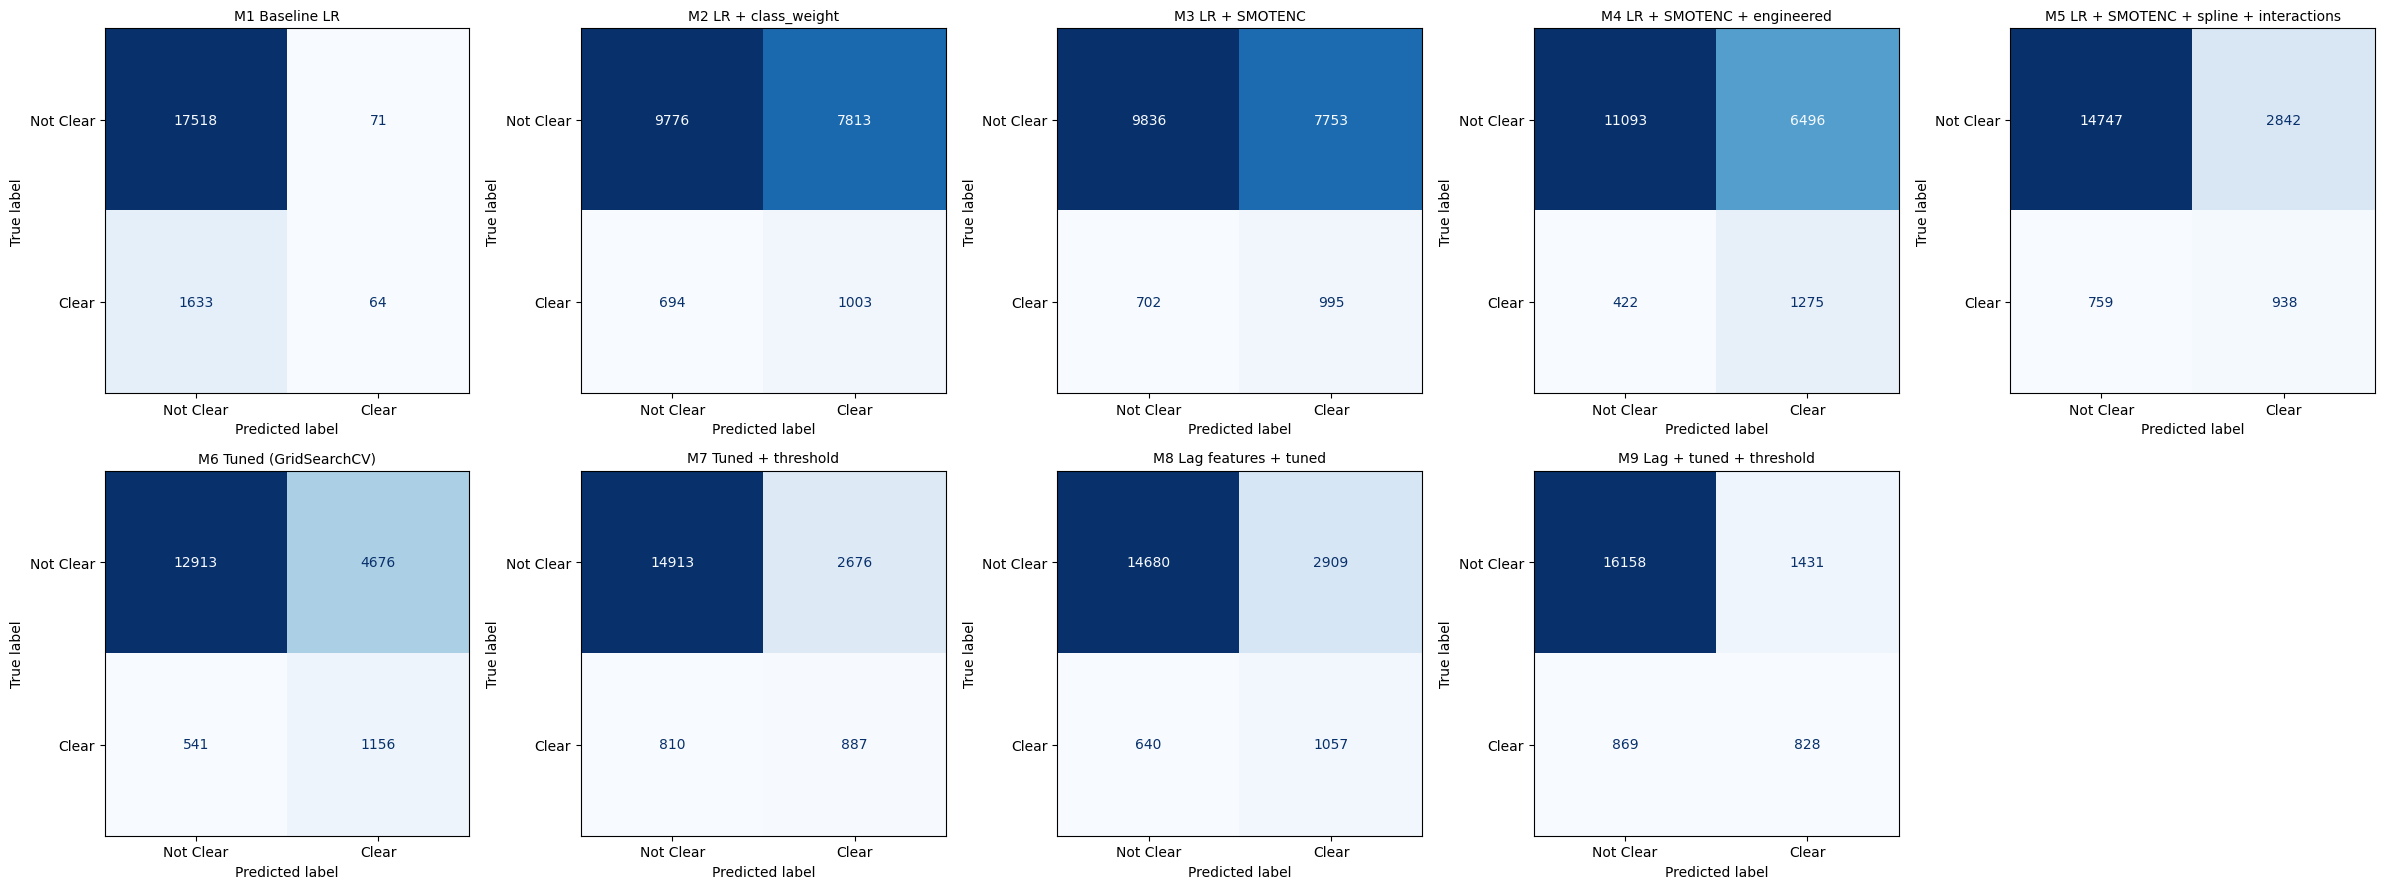

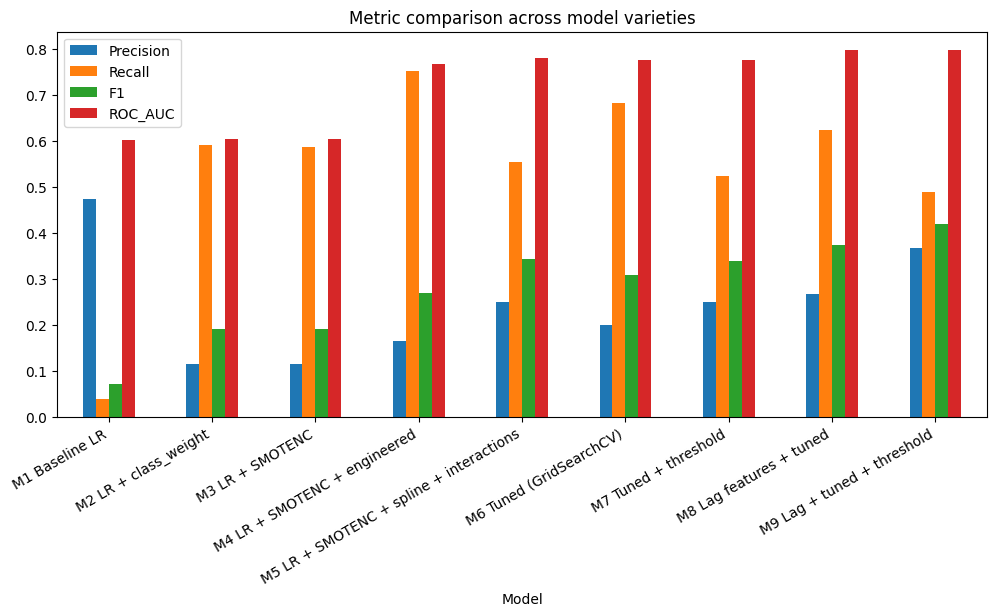

In [25]:
res = pd.DataFrame(results).drop_duplicates(subset='Model', keep='last').set_index('Model').sort_index()
display(res.round(3))

# confusion matrices side by side
fig, axes = plt.subplots(2, 5, figsize=(24, 9)); axes = axes.ravel()
for ax, name in zip(axes, sorted(cms.keys())):
    cm = cms[name]
    ConfusionMatrixDisplay(cm, display_labels=['Not Clear','Clear']).plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(name, fontsize=10)
for ax in axes[len(cms):]: ax.axis('off')
plt.tight_layout(); plt.show()

res[['Precision','Recall','F1','ROC_AUC']].plot(kind='bar', figsize=(12, 5)); plt.xticks(rotation=30, ha='right')
plt.title('Metric comparison across model varieties'); plt.show()

### Why these evaluation metrics?
| Metric | Why it is used here |
|---|---|
| **Accuracy** | *Not a main measure.* Overall correctness, but misleading: ~89% of rows are "Not Clear", so predicting "Not Clear" for everything already gives ~0.89 (see M1). |
| **Precision** | Of the hours predicted "Clear", how many really are Clear (cost of false alarms). |
| **Recall** | Of the truly Clear hours, how many the model finds (cost of missed good hours). |
| **F1 score** | Balances precision and recall; the **main metric used to choose the final model**. |
| **ROC-AUC** | Threshold-independent ranking quality of the predicted probabilities. |
| **PR-AUC** | Threshold-independent and more informative than ROC-AUC for imbalanced data; **used as the scoring in GridSearchCV**. |
| **Confusion matrix** | Shows the actual counts of TP / FP / FN / TN for every variety. |

**Validation method:** chronological 80/20 hold-out (the last 20% of the time line is the test set, held out from model selection and tuning and used only for final performance reporting) + 3-fold `TimeSeriesSplit` cross-validation on the training set, applied to ALL varieties (SMOTENC inside the pipeline, so only the training part of each fold is oversampled). The tuned models M6/M8 are scored with a **nested** CV (grid search repeated inside each outer training fold). The final model is selected by CV F1, **never by the test set**. All CV scores are computed on the same later folds (2 … k). For the final test evaluation, the final M6/M8 hyperparameters (best `C`, best SMOTE `k_neighbors`) are fixed, a `TimeSeriesSplit` CV with these fixed parameters produces out-of-fold probabilities on the training set, and the best-F1 threshold is taken from these pooled predictions; the final model is then refitted on the full training set and evaluated on the test set. The threshold is not selected using the test set. In the CV score of M7/M9 the threshold of each fold comes only from the earlier folds (forward-only).


## 12. Final model (selected by cross-validation) – classification report, summary & confusion matrix


### 12a. Classification report of the final model


In [26]:
# Final model = the one chosen by CROSS-VALIDATION (see section 10c), reported on the held-out test set (not used for selection)
print(f"Final model (selected by CV F1): {final_name}  |  threshold = {final_thr:.3f}\n")
print(classification_report(y_test, final_pred, target_names=['Not Clear', 'Clear']))

Final model (selected by CV F1): M9 Lag + tuned + threshold  |  threshold = 0.659

              precision    recall  f1-score   support

   Not Clear       0.95      0.92      0.93     17589
       Clear       0.37      0.49      0.42      1697

    accuracy                           0.88     19286
   macro avg       0.66      0.70      0.68     19286
weighted avg       0.90      0.88      0.89     19286



### 12b. Final summary – all models, metrics, best model


CROSS-VALIDATION RESULTS (used to SELECT the final model)


,Threshold,CV_F1,CV_F1_std,CV_Precision,CV_Recall,CV_PR_AUC,CV_ROC_AUC,CV_F1_all_folds
Model,,,,,,,,
M1 Baseline LR,0.500,0.043,0.014,0.497,0.023,0.270,0.752,0.038
M2 LR + class_weight,0.500,0.307,0.046,0.195,0.766,0.270,0.752,0.303
M3 LR + SMOTENC,0.500,0.307,0.047,0.195,0.763,0.269,0.753,0.303
M4 LR + SMOTENC + engineered,0.500,0.354,0.045,0.231,0.784,0.340,0.810,0.352
M5 LR + SMOTENC + spline + interactions,0.500,0.409,0.018,0.310,0.605,0.349,0.825,0.396
M6 Tuned (GridSearchCV),0.500,0.400,0.034,0.271,0.768,0.377,0.839,0.391
M7 Tuned + threshold,0.662,0.424,0.025,0.317,0.643,0.377,0.839,NaN
M8 Lag features + tuned,0.500,0.454,0.027,0.327,0.745,0.438,0.859,0.439
M9 Lag + tuned + threshold,0.659,0.479,0.015,0.407,0.584,0.438,0.859,NaN



TEST-SET RESULTS OF ALL VARIETIES (for reporting only, not used for selection)


,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,,
M1 Baseline LR,0.500,0.912,0.474,0.038,0.070,0.602,0.171
M2 LR + class_weight,0.500,0.559,0.114,0.591,0.191,0.604,0.168
M3 LR + SMOTENC,0.500,0.562,0.114,0.586,0.191,0.604,0.167
M4 LR + SMOTENC + engineered,0.500,0.641,0.164,0.751,0.269,0.766,0.259
M5 LR + SMOTENC + spline + interactions,0.500,0.813,0.248,0.553,0.343,0.779,0.326
M6 Tuned (GridSearchCV),0.500,0.729,0.198,0.681,0.307,0.775,0.310
M7 Tuned + threshold,0.662,0.819,0.249,0.523,0.337,0.775,0.310
M8 Lag features + tuned,0.500,0.816,0.267,0.623,0.373,0.797,0.349
M9 Lag + tuned + threshold,0.659,0.881,0.367,0.488,0.419,0.797,0.349


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
M1 Baseline LR,0.912000,0.474000,0.038000,0.070000,0.602000,0.171000
M2 LR + class_weight,0.559000,0.114000,0.591000,0.191000,0.604000,0.168000
M3 LR + SMOTENC,0.562000,0.114000,0.586000,0.191000,0.604000,0.167000
M4 LR + SMOTENC + engineered,0.641000,0.164000,0.751000,0.269000,0.766000,0.259000
M5 LR + SMOTENC + spline + interactions,0.813000,0.248000,0.553000,0.343000,0.779000,0.326000
M6 Tuned (GridSearchCV),0.729000,0.198000,0.681000,0.307000,0.775000,0.310000
M7 Tuned + threshold,0.819000,0.249000,0.523000,0.337000,0.775000,0.310000
M8 Lag features + tuned,0.816000,0.267000,0.623000,0.373000,0.797000,0.349000
M9 Lag + tuned + threshold,0.881000,0.367000,0.488000,0.419000,0.797000,0.349000



Final model (selected by CV F1): M9 Lag + tuned + threshold
  Mean F1 across the later time-series validation folds = 0.479
  Test F1 = 0.419   <- reporting only, not used for selection
(Best on test by F1: M9 Lag + tuned + threshold, best on test by PR-AUC: M8 Lag features + tuned)

Confusion matrix counts:


,TN,FP,FN,TP
Model,,,,
M1 Baseline LR,17518,71,1633,64
M2 LR + class_weight,9776,7813,694,1003
M3 LR + SMOTENC,9836,7753,702,995
M4 LR + SMOTENC + engineered,11093,6496,422,1275
M5 LR + SMOTENC + spline + interactions,14747,2842,759,938
M6 Tuned (GridSearchCV),12913,4676,541,1156
M7 Tuned + threshold,14913,2676,810,887
M8 Lag features + tuned,14680,2909,640,1057
M9 Lag + tuned + threshold,16158,1431,869,828


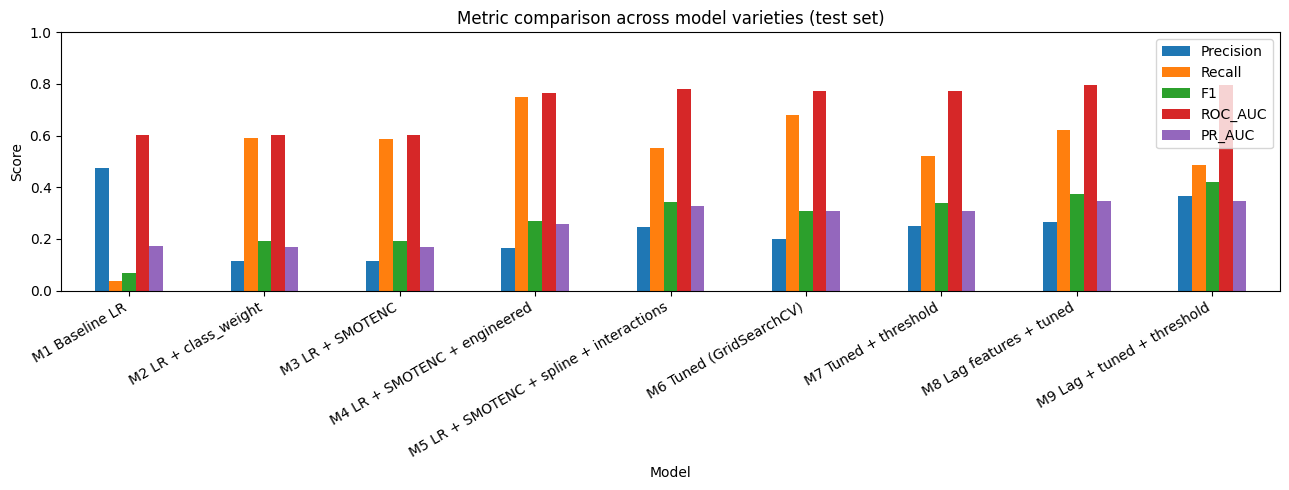

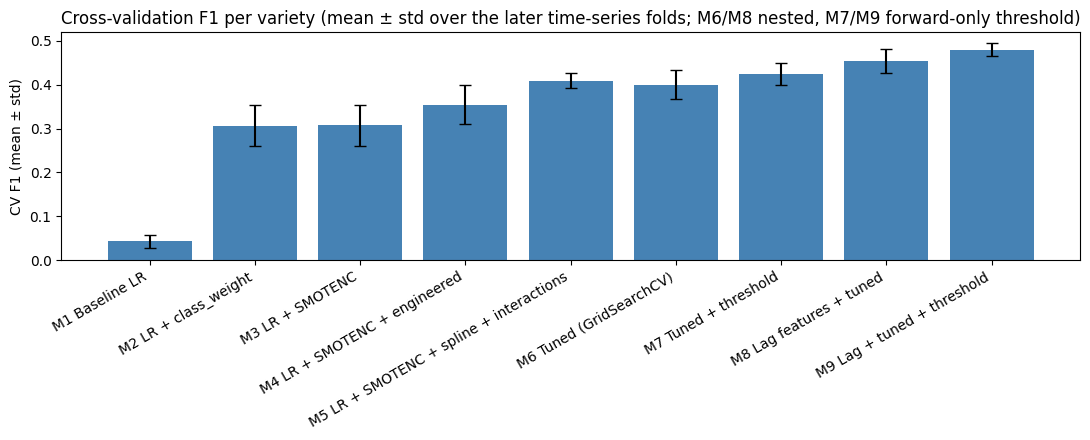

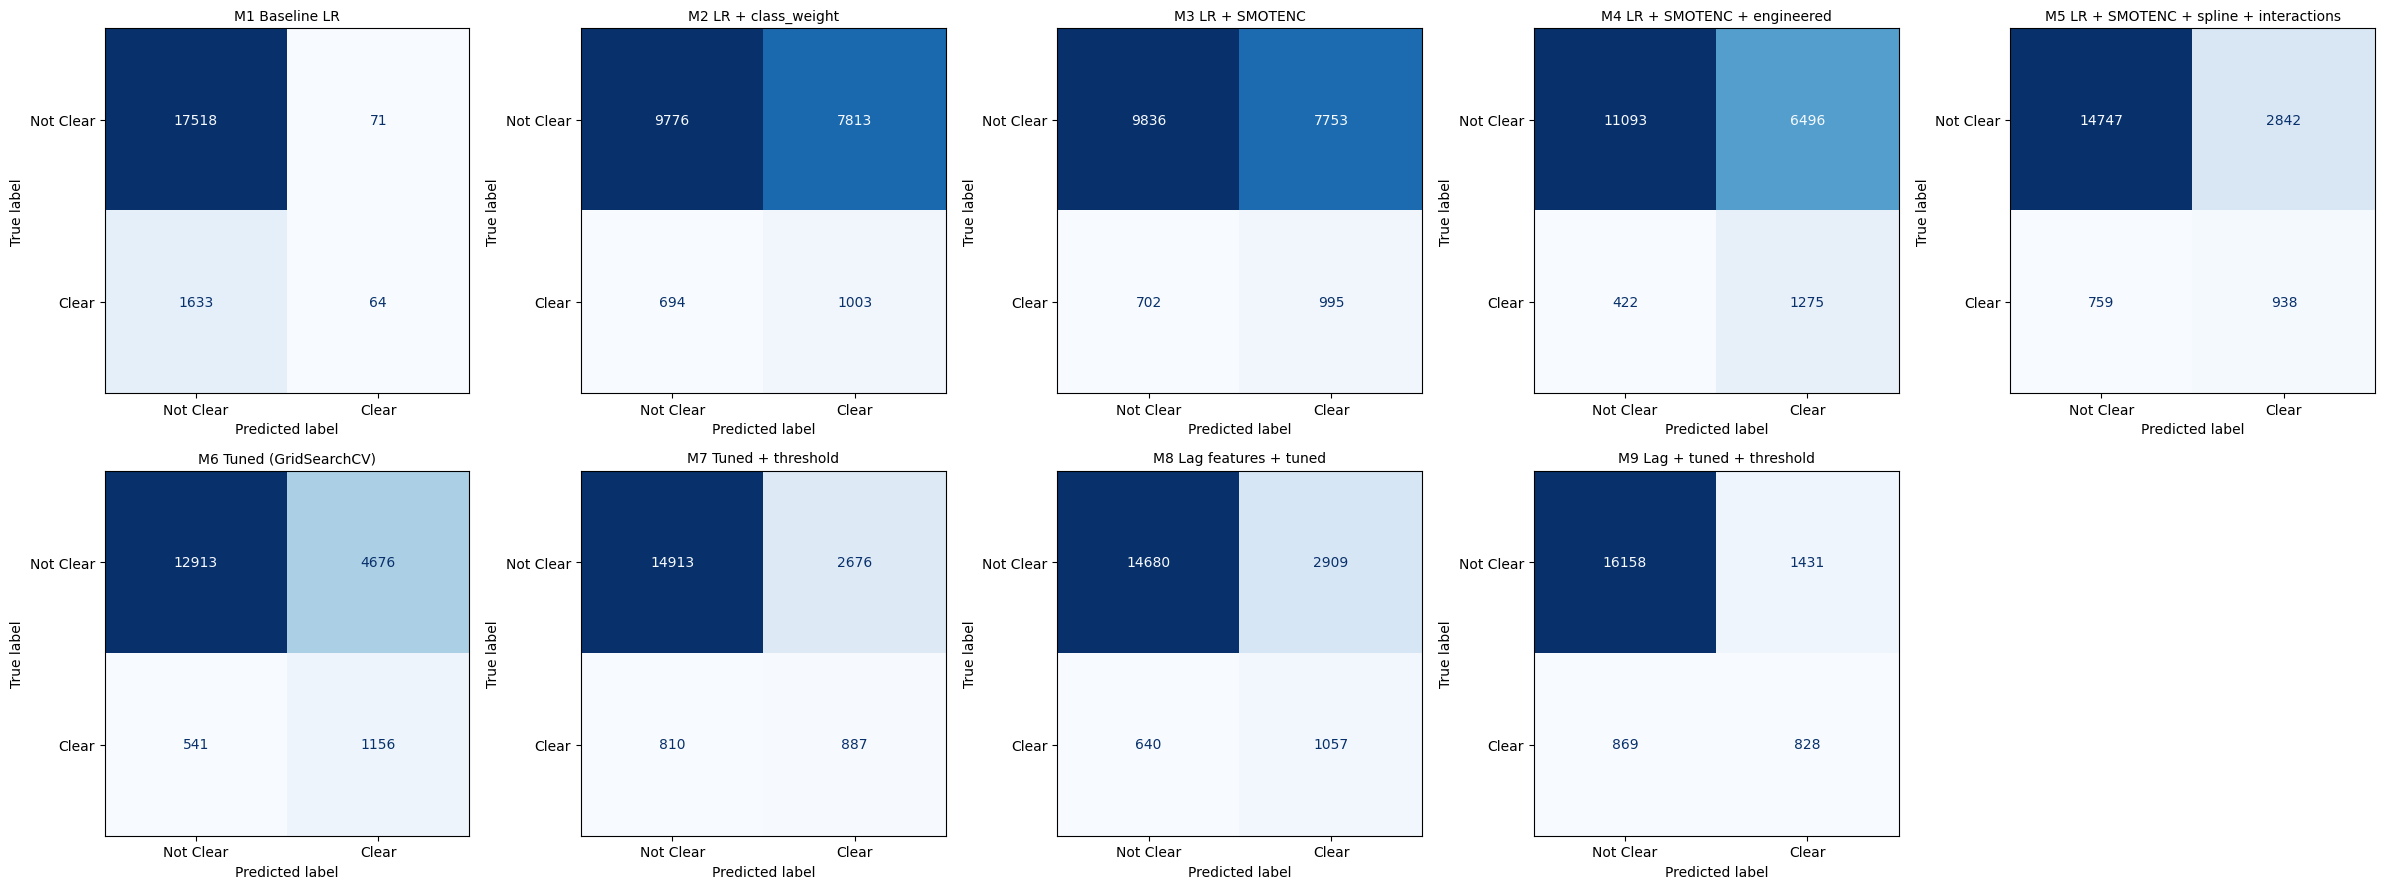

In [27]:
# ===== FINAL SUMMARY: all models, metrics =====
res = (pd.DataFrame(results)
         .drop_duplicates(subset='Model', keep='last')
         .set_index('Model')
         .sort_index())

metric_cols = ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']

print("=" * 70)
print("CROSS-VALIDATION RESULTS (used to SELECT the final model)")
print("=" * 70)
display(cv_table.round(3))

print("\n" + "=" * 70)
print("TEST-SET RESULTS OF ALL VARIETIES (for reporting only, not used for selection)")
print("=" * 70)
display(res[metric_cols].round(3))

# highlight the best value in each column
display(res[metric_cols[1:]].round(3).style.highlight_max(color='lightgreen', axis=0))

print(f"\nFinal model (selected by CV F1): {final_name}")
print(f"  Mean F1 across the later time-series validation folds = {cv_table.loc[final_name, 'CV_F1']:.3f}")
print(f"  Test F1 = {res.loc[final_name, 'F1']:.3f}   <- reporting only, not used for selection")

# for information only (NOT used for any decision): which model looks best on the test set
print(f"(Best on test by F1: {res['F1'].idxmax()}, best on test by PR-AUC: {res['PR_AUC'].idxmax()})")

# confusion-matrix counts
print("\nConfusion matrix counts:")
display(res[['TN', 'FP', 'FN', 'TP']])

# bar chart of the main metrics
res[['Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']].plot(kind='bar', figsize=(13, 5))
plt.xticks(rotation=30, ha='right')
plt.title('Metric comparison across model varieties (test set)')
plt.ylabel('Score'); plt.ylim(0, 1); plt.tight_layout(); plt.show()

# CV F1 with error bars (the basis of model selection)
cvp = cv_table.dropna(subset=['CV_F1_std'])
plt.figure(figsize=(11, 4.5))
plt.bar(cvp.index, cvp['CV_F1'], yerr=cvp['CV_F1_std'], capsize=4, color='steelblue')
plt.xticks(rotation=30, ha='right'); plt.ylabel('CV F1 (mean ± std)')
plt.title('Cross-validation F1 per variety (mean ± std over the later time-series folds; M6/M8 nested, M7/M9 forward-only threshold)')
plt.tight_layout(); plt.show()

# confusion matrices of all models
fig, axes = plt.subplots(2, 5, figsize=(24, 9)); axes = axes.ravel()
for ax, name in zip(axes, sorted(cms.keys())):
    ConfusionMatrixDisplay(cms[name], display_labels=['Not Clear', 'Clear']).plot(
        ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(name, fontsize=10)
for ax in axes[len(cms):]: ax.axis('off')
plt.tight_layout(); plt.show()

### 12c. Accuracy and F1 score of all models
*Accuracy is shown for completeness only. With ~89% 'Not Clear' hours it is misleading (a model that never predicts Clear already scores ~0.89), so models are compared with F1 / PR-AUC / precision / recall, and selected by CV F1.*


,Accuracy,F1,CV_F1
Model,,,
M1 Baseline LR,0.912,0.070,0.043
M2 LR + class_weight,0.559,0.191,0.307
M3 LR + SMOTENC,0.562,0.191,0.307
M4 LR + SMOTENC + engineered,0.641,0.269,0.354
M5 LR + SMOTENC + spline + interactions,0.813,0.343,0.409
M6 Tuned (GridSearchCV),0.729,0.307,0.400
M7 Tuned + threshold,0.819,0.337,0.424
M8 Lag features + tuned,0.816,0.373,0.454
M9 Lag + tuned + threshold,0.881,0.419,0.479


Final model: M9 Lag + tuned + threshold (Test Accuracy = 0.881, Test F1 = 0.419)


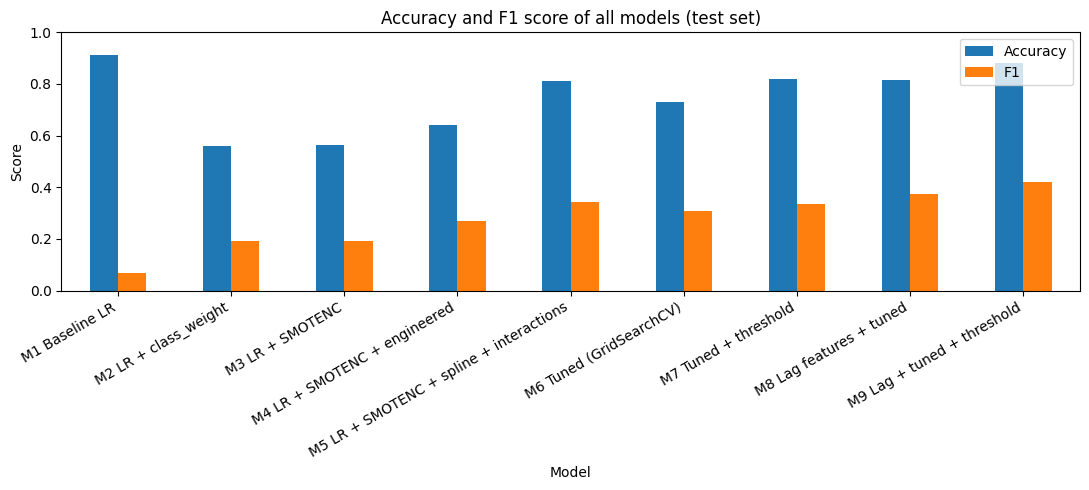

In [28]:
res = (pd.DataFrame(results)
         .drop_duplicates(subset='Model', keep='last')
         .set_index('Model')
         .sort_index())

summary = res[['Accuracy', 'F1']].round(3)
summary['CV_F1'] = cv_table['CV_F1'].round(3)
display(summary)

best = final_name          # chosen by cross-validation, not by the test set
print(f"Final model: {best} (Test Accuracy = {summary.loc[best, 'Accuracy']}, Test F1 = {summary.loc[best, 'F1']})")

summary[['Accuracy', 'F1']].plot(kind='bar', figsize=(11, 5))
plt.xticks(rotation=30, ha='right')
plt.title('Accuracy and F1 score of all models (test set)')
plt.ylabel('Score'); plt.ylim(0, 1)
plt.tight_layout(); plt.show()

### 12d. Confusion matrix of the best model


Final model: M9 Lag + tuned + threshold (Test F1 = 0.419)


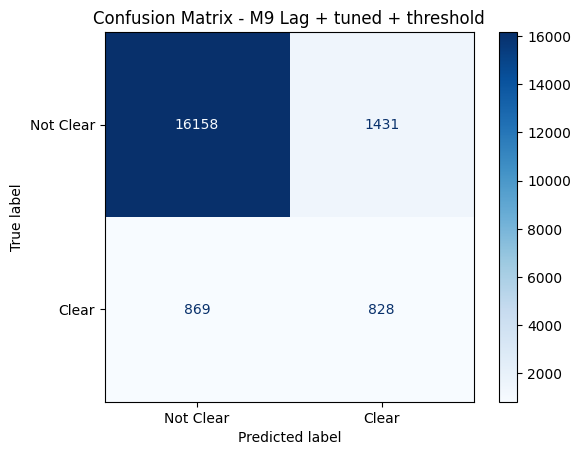

In [29]:
best = final_name          # chosen by cross-validation

print(f"Final model: {best} (Test F1 = {res.loc[best, 'F1']:.3f})")

ConfusionMatrixDisplay(cms[best], display_labels=['Not Clear', 'Clear']).plot(
    cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best}')
plt.show()

### Conclusion


In [30]:
# ---- Conclusion (generated from the tables) ----
r = (pd.DataFrame(results).drop_duplicates(subset='Model', keep='last').set_index('Model').sort_index())
base, best_name = r.loc['M1 Baseline LR'], final_name
b = r.loc[best_name]
print(f"Final model (selected by CV F1, NOT by the test set): {best_name}")
print(f"  Mean F1 across the later time-series validation folds = {cv_table.loc[best_name, 'CV_F1']:.3f}  |  Test F1 = {b['F1']:.3f}   (test = reporting only)")
print("  (This is an estimate based on only the later validation periods, not a general performance guarantee; the test set has a different Clear rate.)")
print(f"  Precision: {base['Precision']:.3f} (M1) -> {b['Precision']:.3f}")
print(f"  Recall   : {base['Recall']:.3f} (M1) -> {b['Recall']:.3f}")
print(f"  F1       : {base['F1']:.3f} (M1) -> {b['F1']:.3f}")
print(f"  PR-AUC   : {base['PR_AUC']:.3f} (M1) -> {b['PR_AUC']:.3f}")
print(f"  ROC-AUC  : {base['ROC_AUC']:.3f} (M1) -> {b['ROC_AUC']:.3f}")
print(f"  (Accuracy {base['Accuracy']:.3f} (M1) -> {b['Accuracy']:.3f}: NOT a main measure, M1 has high accuracy only because it almost never predicts 'Clear')")

print("\nStep-by-step: model selection is based on CV F1; test F1 is shown for reporting only")
display(pd.DataFrame({'CV_F1': cv_table['CV_F1'], 'CV_F1_std': cv_table['CV_F1_std'],
                      'Gain_CV_vs_previous': cv_table['CV_F1'].diff(),
                      'Test_F1 (report only)': r['F1']}).round(3))

# ---- key comparisons, generated from the tables (so the text always matches the results) ----
M = {k_: [x for x in cv_table.index if x.startswith(k_ + ' ')][0] for k_ in ['M1','M2','M3','M4','M5','M6','M7','M8','M9']}
cvv = lambda k_, col='CV_F1': cv_table.loc[M[k_], col]
tst = lambda k_, col='F1': r.loc[M[k_], col]
def verdict(a_, b_):      # heuristic only (NOT a statistical test): is the CV difference larger than the observed fold-to-fold spread?
    d_ = cvv(b_) - cvv(a_); sd_ = max(cvv(a_, 'CV_F1_std'), cvv(b_, 'CV_F1_std'))
    return f"diff {d_:+.3f} vs CV std {sd_:.3f} -> " + ("difference larger than the observed fold-to-fold variation" if abs(d_) > sd_ else "difference not larger than the observed fold-to-fold variation (within CV noise)")
print("\nKey comparisons - conclusions come from CV; test values in brackets are for reporting only:")
print(f"- Imbalance handling : CV F1 M2 class_weight {cvv('M2'):.3f} vs M3 SMOTENC {cvv('M3'):.3f}  [{verdict('M2','M3')}]  (test {tst('M2'):.3f} vs {tst('M3'):.3f})")
print(f"- Engineered feature representation (cyclic encodings + a different raw-feature subset, so NOT a pure cyclic-encoding effect): CV F1 M3 {cvv('M3'):.3f} -> M4 {cvv('M4'):.3f} -> M5 {cvv('M5'):.3f}  (test {tst('M3'):.3f} -> {tst('M4'):.3f} -> {tst('M5'):.3f})")
print(f"- Tuning (nested CV) : CV F1 M5 {cvv('M5'):.3f} vs M6 {cvv('M6'):.3f}  [{verdict('M5','M6')}]  (test {tst('M5'):.3f} vs {tst('M6'):.3f}; final-search params {grid.best_params_})")
print(f"- Lag features       : CV PR-AUC M6 {cvv('M6','CV_PR_AUC'):.3f} -> M8 {cvv('M8','CV_PR_AUC'):.3f}; CV F1 {cvv('M6'):.3f} -> {cvv('M8'):.3f}  [{verdict('M6','M8')}]  (test PR-AUC {tst('M6','PR_AUC'):.3f} -> {tst('M8','PR_AUC'):.3f})")
print(f"- Threshold tuning   : CV P/R M8 {cvv('M8','CV_Precision'):.3f}/{cvv('M8','CV_Recall'):.3f} -> M9 {cvv('M9','CV_Precision'):.3f}/{cvv('M9','CV_Recall'):.3f}  (test {tst('M8','Precision'):.3f}/{tst('M8','Recall'):.3f} -> {tst('M9','Precision'):.3f}/{tst('M9','Recall'):.3f})")
gap = (cv_table['CV_F1'] - r['F1']).abs()
print(f"- CV vs test F1      : largest gap over all models = {gap.max():.3f} ({gap.idxmax()}); final model gap = {gap[best_name]:.3f}")
print(f"- Class drift        : Clear rate train {y_train.mean():.3f} vs test {y_test.mean():.3f}")
print("  (CV folds cover earlier years, the test set the latest years -> a gap may reflect class drift / a changing weather pattern over time, in addition to the overall ~11% Clear rate)")

Final model (selected by CV F1, NOT by the test set): M9 Lag + tuned + threshold
  Mean F1 across the later time-series validation folds = 0.479  |  Test F1 = 0.419   (test = reporting only)
  (This is an estimate based on only the later validation periods, not a general performance guarantee; the test set has a different Clear rate.)
  Precision: 0.474 (M1) -> 0.367
  Recall   : 0.038 (M1) -> 0.488
  F1       : 0.070 (M1) -> 0.419
  PR-AUC   : 0.171 (M1) -> 0.349
  ROC-AUC  : 0.602 (M1) -> 0.797
  (Accuracy 0.912 (M1) -> 0.881: NOT a main measure, M1 has high accuracy only because it almost never predicts 'Clear')

Step-by-step: model selection is based on CV F1; test F1 is shown for reporting only


,CV_F1,CV_F1_std,Gain_CV_vs_previous,Test_F1 (report only)
Model,,,,
M1 Baseline LR,0.043,0.014,NaN,0.070
M2 LR + class_weight,0.307,0.046,0.264,0.191
M3 LR + SMOTENC,0.307,0.047,0.000,0.191
M4 LR + SMOTENC + engineered,0.354,0.045,0.047,0.269
M5 LR + SMOTENC + spline + interactions,0.409,0.018,0.055,0.343
M6 Tuned (GridSearchCV),0.400,0.034,-0.009,0.307
M7 Tuned + threshold,0.424,0.025,0.025,0.337
M8 Lag features + tuned,0.454,0.027,0.030,0.373
M9 Lag + tuned + threshold,0.479,0.015,0.026,0.419



Key comparisons - conclusions come from CV; test values in brackets are for reporting only:
- Imbalance handling : CV F1 M2 class_weight 0.307 vs M3 SMOTENC 0.307  [diff +0.000 vs CV std 0.047 -> difference not larger than the observed fold-to-fold variation (within CV noise)]  (test 0.191 vs 0.191)
- Engineered feature representation (cyclic encodings + a different raw-feature subset, so NOT a pure cyclic-encoding effect): CV F1 M3 0.307 -> M4 0.354 -> M5 0.409  (test 0.191 -> 0.269 -> 0.343)
- Tuning (nested CV) : CV F1 M5 0.409 vs M6 0.400  [diff -0.009 vs CV std 0.034 -> difference not larger than the observed fold-to-fold variation (within CV noise)]  (test 0.343 vs 0.307; final-search params {'lr__C': 0.001, 'smote__k_neighbors': 3})
- Lag features       : CV PR-AUC M6 0.377 -> M8 0.438; CV F1 0.400 -> 0.454  [diff +0.054 vs CV std 0.034 -> difference larger than the observed fold-to-fold variation]  (test PR-AUC 0.310 -> 0.349)
- Threshold tuning   : CV P/R M8 0.327/0.745 -> M9

Threshold  Precision  Recall  \
Variant       Threshold type                                              
With SMOTE    threshold 0.5                    0.500      0.267   0.623   
              train-OOF best-F1 threshold      0.659      0.367   0.488   
Without SMOTE threshold 0.5                    0.500      0.579   0.191   
              train-OOF best-F1 threshold      0.262      0.409   0.485   

                                              F1  PR_AUC     TN    FP    FN  \
Variant       Threshold type                                                  
With SMOTE    threshold 0.5                0.373   0.349  14680  2909   640   
              train-OOF best-F1 threshold  0.419   0.349  16158  1431   869   
Without SMOTE threshold 0.5                0.287   0.409  17353   236  1373   
              train-OOF best-F1 threshold  0.444   0.409  16400  1189   874   

                                             TP  
Variant       Threshold type                     
With SMOTE    threshold 0.5                1057  
              train-OOF best-F1 threshold   828  
Without SMOTE threshold 0.5                 324  
              train-OOF best-F1 threshold   823

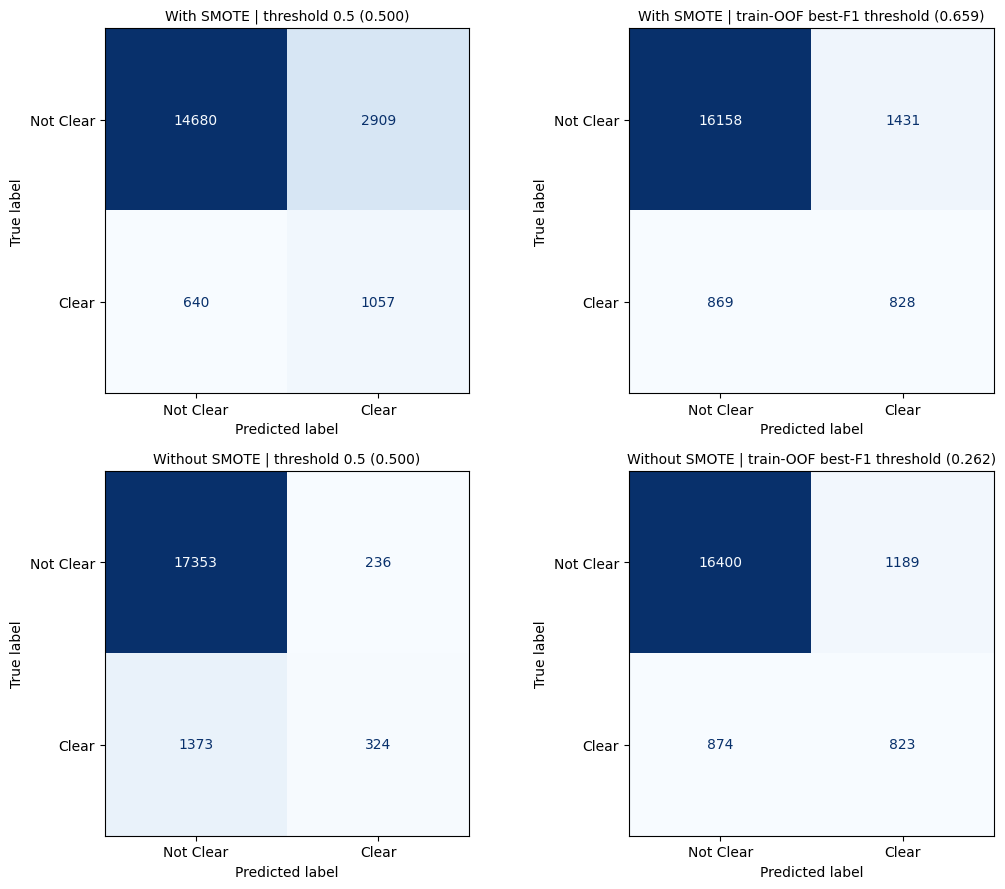

In [31]:
# ===== SUMMARY: confusion matrices WITH vs WITHOUT SMOTE (final lag-feature model M8/M9) =====
# Same pipeline, same tuned C, same features; the only difference is that the 'smote' step is removed.
# The test set is used for REPORTING only (no model/threshold is selected on it).
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def without_smote(est):
    return ImbPipeline([(n, clone(s)) for n, s in est.steps if n != 'smote'])

def oof_threshold(est, X, y):
    """best-F1 threshold from pooled out-of-fold predictions on the TRAIN set (TimeSeriesSplit)"""
    probs, ys = [], []
    for a, b in cv.split(X):
        m = clone(est).fit(X.iloc[a], y.iloc[a])
        probs.append(m.predict_proba(X.iloc[b])[:, 1]); ys.append(y.iloc[b].values)
    return best_f1_threshold(np.concatenate(ys), np.concatenate(probs))[0]

est_with = clone(pipe_lag).set_params(**grid_lag.best_params_)
est_wo   = without_smote(pipe_lag).set_params(lr__C=grid_lag.best_params_['lr__C'])
variants = {'With SMOTE': est_with, 'Without SMOTE': est_wo}

rows, cms_ab = [], {}
for vname, est in variants.items():
    m = clone(est).fit(Xl_train, y_train)
    p = m.predict_proba(Xl_test)[:, 1]
    thr_oof = oof_threshold(est, Xl_train, y_train)
    for tname, t in [('threshold 0.5', 0.5), ('train-OOF best-F1 threshold', thr_oof)]:
        pred = (p >= t).astype(int)
        cm = confusion_matrix(y_test, pred); cms_ab[(vname, tname)] = (cm, t)
        rows.append({'Variant': vname, 'Threshold type': tname, 'Threshold': round(t, 3),
                     'Precision': precision_score(y_test, pred, zero_division=0), 'Recall': recall_score(y_test, pred),
                     'F1': f1_score(y_test, pred), 'PR_AUC': average_precision_score(y_test, p),
                     'TN': cm[0, 0], 'FP': cm[0, 1], 'FN': cm[1, 0], 'TP': cm[1, 1]})
display(pd.DataFrame(rows).set_index(['Variant', 'Threshold type']).round(3))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, ((vname, tname), (cm, t)) in zip(axes.ravel(), cms_ab.items()):
    ConfusionMatrixDisplay(cm, display_labels=['Not Clear', 'Clear']).plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{vname} | {tname} ({t:.3f})', fontsize=10)
plt.tight_layout(); plt.show()

In [32]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score

# same pipeline & tuned C; the only difference is the 'smote' step
est_with = clone(pipe_lag).set_params(**grid_lag.best_params_)
est_wo   = ImbPipeline([(n, clone(s)) for n, s in pipe_lag.steps if n != 'smote']) \
               .set_params(lr__C=grid_lag.best_params_['lr__C'])

rows = []
for name, est in {'With SMOTE': est_with, 'Without SMOTE': est_wo}.items():
    m = clone(est).fit(Xl_train, y_train)
    for split, X, y in [('Train', Xl_train, y_train), ('Test', Xl_test, y_test)]:
        pred = m.predict(X)                      # threshold 0.5
        rows.append({'Model': name, 'Split': split,
                     'Accuracy': accuracy_score(y, pred), 'F1': f1_score(y, pred)})

display(pd.DataFrame(rows).set_index(['Model', 'Split']).round(3))

Accuracy     F1
Model         Split                 
With SMOTE    Train     0.811  0.499
              Test      0.816  0.373
Without SMOTE Train     0.895  0.367
              Test      0.917  0.287

In [33]:
from sklearn.metrics import accuracy_score, f1_score

print("Final model:", final_name, "| threshold:", round(final_thr, 3))
print("Accuracy:", round(accuracy_score(y_test, final_pred), 3))
print("F1 score:", round(f1_score(y_test, final_pred), 3))

Final model: M9 Lag + tuned + threshold | threshold: 0.659
Accuracy: 0.881
F1 score: 0.419


## 13. Explanation (for the review)

*All result numbers (F1, precision, recall, AUC, thresholds, number of fits) are printed by the cells above (sections 10c, 10d, 12, Conclusion), so this text contains no hard-coded results and cannot get out of sync with them.*

- **Suitability of the model:** The target is binary (Clear = suitable, Not Clear = not suitable), so Logistic Regression is a natural classifier. It is fast, interpretable and outputs probabilities, so the decision threshold can be tuned for an imbalanced problem. Its weakness is that it is linear, so non-linear structure (hour of day, season, visibility) had to be added by hand through feature engineering, splines and interactions.

- **Target definition – nowcast, not forecast:** "Suitable" = `Summary == 'Clear'`. This is strict (Partly Cloudy is counted as not suitable) and the weather features are measured in the **same hour** as the label, so the task is a *nowcast* (classification of the current sky condition from current and past readings), **not a forecast** of future weather.

- **Pre-processing and its assumptions:** Exact duplicates removed; the data is **sorted by time first** (the raw file is not in time order).
  - *Missing `Precip Type` (assumption):* forward-filled using the **most recent known previous value**. A gap can last more than one hour, so the assumption is that the last known precipitation type is still valid during the gap. Only a very small share of rows is affected; section 2 prints the longest gap and how often the type is unchanged between consecutive known hours as supporting evidence. Because the data is sorted first, only past information is used (no future → past leakage).
  - *`Pressure = 0` (assumption):* treated as a faulty / missing reading because 0 millibars is physically impossible at the earth's surface (valid readings are around 1000 mb). The dataset documentation does not state this, so it is **our assumption**; the rows are flagged with `Pressure_Missing` and the value is replaced by the median of the training period.
  - `Loud Cover` dropped (constant 0); hour, month and wind direction (`Wind_Bearing`, a 0–360° circular variable) encoded cyclically (sin/cos) in the engineered models M4–M9 (the raw baseline M1–M3 keeps the raw `Wind_Bearing`); `Temp_Difference` and `Wind_Humidity` added; `Year` is not used as a feature (the test years lie outside the training years); `StandardScaler` fitted on the training data only (inside the pipelines).
  - M8/M9 add lagged and rolling historical features (shift / rolling over previous hours, past values only) together with current-to-past change features (`_chg1`, `_chg3` use the current-hour value, which is allowed for a nowcast but would be leakage in a forecast). The first 24 rows are excluded as a warm-up period so that all lag/rolling features, including the 24-hour rolling statistics, have complete historical information. They serve only as history and are excluded from training/CV of all models (so lags are not filled artificially).

- **Implementation (libraries and functions):** scikit-learn `LogisticRegression` (`lbfgs`, L2 penalty, `max_iter` = 2000 for M1–M4 and 1000 for the larger M5–M9; convergence warnings are not suppressed), `StandardScaler`, `SplineTransformer` (6 knots, degree 3), `PolynomialFeatures` (degree 3 for M5–M7, degree 2 for M8–M9), `ColumnTransformer`, `FeatureUnion`, `GridSearchCV`, `TimeSeriesSplit`; imbalanced-learn `SMOTENC` (and `SMOTE` for the comparison in section 7b) and `imblearn.pipeline.Pipeline`.

- **Class imbalance:** Only about 11% of rows are Clear overall. Because the split is chronological, the Clear rate of the training and test periods can differ (class drift; both rates are printed in the split cell and in the Conclusion), so the overall ~11% should not be assumed for either part. `SMOTENC` (SMOTE for mixed continuous/binary features) is applied to the training data only, inside the pipeline, so in every CV fold it only touches the training part and never the validation fold or the test set. For M5–M9 it is applied *before* the spline/polynomial expansion, so synthetic points are real points of the feature space that are then expanded consistently. `class_weight` and SMOTE are not combined (M2 uses `class_weight='balanced'` alone, M3 uses SMOTE alone), so the classes are not balanced twice.

- **Validation method:** chronological 80/20 split (last 20% of the time line = test set, held out from model selection and tuning, used only for final performance reporting) and 3-fold `TimeSeriesSplit`, so a model is never trained on hours that come after the hours it is validated on. Every variety is cross-validated and the **final model is selected by CV F1, never by the test set**. The tuned models M6/M8 are scored with a **nested CV** (the grid search is repeated inside each outer training fold), so their CV F1 is not biased by tuning on the same folds. For the threshold models (M7/M9) the CV score uses a forward-only threshold (each fold's threshold comes only from earlier folds), so all CV scores are computed on the same later folds (2 … k). For the final test evaluation, the final M6/M8 hyperparameters (best `C`, best SMOTE `k_neighbors`) are fixed, a `TimeSeriesSplit` CV with these fixed parameters produces out-of-fold probabilities on the training set, and the best-F1 threshold is taken from these pooled predictions; the final model is then refitted on the full training set and evaluated on the test set. The threshold is not selected using the test set.

- **Parameter tuning method:** `GridSearchCV` (3-fold `TimeSeriesSplit`, scoring = PR-AUC) over `C` ∈ {0.001, 0.01, 0.1} and SMOTE `k_neighbors` ∈ {3, 5} = 6 combinations × 3 folds = 18 fits per search, run twice (M6 on the engineered features, M8 on the lag features). **`TUNE_FRAC = 1.0`, so the full chronological training set was used for hyperparameter tuning** (`C` and `k_neighbors` are selected on the full training data); the best parameters were then refitted on the full training set. M5 uses a manually chosen `C = 0.1`. Threshold tuning (M7, M9) adds no new models, only a new decision cut-off.

- **Number of fits (not just "models"):** section 10d separates three kinds of fits: (1) *final fits* (the models evaluated on the test set), (2) *grid-search fits* (6 combinations × 3 inner folds per search) and (3) *model-selection CV fits* (3 per model for M1–M5; for the nested CV of M6/M8: 3 outer folds × (18 inner grid fits + 1 refit)). M7/M9 need no new fits. Adding the three columns gives the total printed in section 10d.

- **Number and variety of models:** Nine varieties (M1–M9) were built. They differ in pre-processing (raw features, engineered features, splines + interactions, lag/rolling features), imbalance handling (none, `class_weight='balanced'`, SMOTENC) and tuning (none, manual `C`, GridSearchCV, threshold tuning).
  - **M1–M3** use the scaled raw features (baseline, `class_weight`, SMOTENC).
  - **M4** uses an *engineered feature representation* with SMOTENC: cyclic sin/cos encodings of hour, month and wind direction, a `Pressure_Missing` flag, and a **different feature subset** than M1–M3 (`Apparent_Temperature`, `Wind_Humidity`, `Day`, `Day_of_week` and the raw `Hour`/`Month`/`Wind_Bearing` are removed or replaced). The M3 → M4 difference is therefore not caused by the cyclic encoding alone.
  - **M5** adds splines and polynomial interactions (degree 3) with a manually chosen `C = 0.1`.
  - **M6** is M5 tuned with GridSearchCV.
  - **M7** is M6 with a tuned decision threshold.
  - **M8** adds lagged/rolling historical features and current-to-past change features and is tuned with GridSearchCV.
  - **M9** is M8 with a tuned decision threshold.
  - **M7 and M9 are treated as separate model configurations because decision-threshold selection is part of their modelling procedure.** Their CV F1 includes the threshold-selection step (forward-only), so selecting the final model by CV F1 compares complete procedures.

- **Evaluation metrics and why:** **Accuracy is not a main measure**: about 89% of rows are Not Clear, so a model that never predicts Clear already gets ~0.89. Models are therefore compared with **Precision, Recall and F1** (of the Clear class), **PR-AUC** (informative on imbalanced data, used as the GridSearchCV score), **ROC-AUC** (ranking quality) and the confusion matrix. F1 (CV) is the main metric for choosing the final model.

- **Comparison and conclusion:** see the *Key comparisons* printed under "Conclusion". Conclusions about which step helps (imbalance handling, engineered feature representation, tuning, lag features, threshold) must be based on the **CV results** and on whether the difference is larger than the fold-to-fold spread (the cell prints this check). The test results are only used to report the final model; e.g. "tuning improved/did not improve M5" must be concluded from the nested CV, not from the test set.

- **Limitations:**
  - Logistic Regression is linear, so non-linear structure had to be added manually (splines and polynomial interactions). This makes the model large (several hundred features for M5–M7, over a thousand for M8–M9) and much harder to interpret than a plain Logistic Regression.
  - The available features carry limited information about "Clear" (there is no cloud-cover information, `Loud Cover` is all zeros), so precision stays modest: part of the hours the final model labels "Clear" are not Clear, and part of the Clear hours are missed (see precision / recall of the final model).
  - The target is strict (`Clear` only) and the features come from the same hour as the label, so the model is a nowcast and not a weather forecast. The lag/rolling features (M8, M9) also need the weather of the previous hours.
  - The test set is the last 20% of the time line, so the result also shows how well the model transfers to later years; the share of Clear hours and the weather pattern change over time (see the printed class drift).
  - **Hyperparameters were searched on the full chronological training set (`TUNE_FRAC = 1.0`)**; the grid is small, and `penalty`, spline settings and polynomial degree were not tuned. `C = 0.1` for M5 was chosen manually. If the differences between grid candidates are smaller than the CV standard deviation (see the tuning table), tuning gives almost no gain.
  - **Hyperparameter stability:** the nested CV chooses the parameters again inside every outer fold; if they differ between folds (see the table printed in section 10d, e.g. different `k_neighbors`), the tuning is not stable and the differences between grid candidates are small compared with the noise.
  - The nested CV removes the tuning bias from the CV score of M6/M8, but the final M6/M8 parameters come from one search on the full training set, and the threshold is an estimate from out-of-fold predictions of models trained on less data than the final model (trained on the earlier part of the training set).
  - With 3 `TimeSeriesSplit` folds the CV scores average only the 2 later folds (report them as "mean F1 across the later time-series validation folds", not as a general performance guarantee) (fold 1 is needed to choose the first forward-only threshold), so the CV standard deviation is a rough estimate based on 2 values. **Model selection was based on only two later validation periods because the first `TimeSeriesSplit` fold cannot support the forward-only threshold procedure.**
  - Assumptions that are not confirmed by the dataset documentation: forward-filled `Precip Type` and `Pressure = 0` as a faulty reading (see Pre-processing).
  - **Oversampling limitation:** plain SMOTE would create invalid fractional values in the binary columns (`Precip_*`, `Pressure_Missing`, e.g. `Precip_Rain = 0.37`), so SMOTENC is used (section 7b prints how often plain SMOTE does this). SMOTENC still interpolates the continuous and cyclic features linearly, so synthetic points are not always realistic hours. Section 7b also compares class_weight, plain SMOTE and SMOTENC: for Logistic Regression oversampling shows no clear benefit over `class_weight='balanced'` when the F1 values are close (compare M2 and M3), so the simpler class_weight is an equally valid choice.

- **Possible improvements:** Tune with a wider grid (`C`, `penalty`, spline knots, polynomial degree, `class_weight` vs SMOTE); other resampling methods (ADASYN, SMOTE-Tomek); a less strict definition of "suitable" (e.g. Clear + Partly Cloudy, or a rule based on temperature, wind and precipitation); tree-based models (Random Forest / Gradient Boosting) that handle non-linearity directly.

## 14. Wording guide for the report (to keep the report consistent with the notebook)

| Topic | Write | Do not write |
|---|---|---|
| Lag features | "M8/M9 add lagged and rolling historical features, together with current-to-past change features" | "M8/M9 use only past values" (the `_chg` features use the current-hour value; allowed for a nowcast, leakage for a forecast) |
| Task | "*nowcast* / classification of whether the **current** hour is Clear (suitable) from current and past weather readings" | "weather suitability **forecast / prediction of future weather**" |
| Model selection | "models were compared and the final model selected by **cross-validated F1** (nested CV for the tuned models)" | "the best model on the test set was chosen" |
| Test set | "the test set was held out from model selection and tuning and was used only for final performance reporting" | "the test set was used only once / only for the final model" (test results of all varieties are printed), "tuning improved M5 → M6" (concluded from the test set) |
| Threshold | "the final M6/M8 hyperparameters were fixed; a time-series CV with these fixed parameters produced out-of-fold probabilities on the training set, and the best-F1 threshold from them was applied to the final model on the test set; the threshold was not selected using the test set" | "the threshold of each fold was chosen from the other folds" (this would include future folds); "the threshold comes from the nested-CV models" (their hyperparameters differ from the final model) |
| CV result | "mean F1 across the later time-series validation folds was X; model selection rests on only two later validation periods because the first `TimeSeriesSplit` fold cannot support the forward-only threshold procedure" | "the model has F1 = X" (as a general performance guarantee) |
| Metrics | "Precision, Recall, F1 and PR-AUC are the main measures; accuracy is misleading (~89% majority class)" | "accuracy of 88% shows the model is good" |
| Tuning | "`TUNE_FRAC = 1.0`, so the full chronological training set was used for hyperparameter tuning" (state it exactly like this; if `TUNE_FRAC` is changed, state the fraction used instead) | "hyperparameters were tuned on a 20% subsample" (not true for the current code) |
| Cost | "N model **fits**: final fits + grid-search fits + model-selection CV fits (section 10d)" | one "models trained" number without the breakdown |
| Oversampling | "SMOTENC was used so that the binary variables keep valid 0/1 values; the continuous and cyclic features are still interpolated linearly (limitation). SMOTE/SMOTENC showed no clear benefit over `class_weight='balanced'` (compare M2 and M3 and section 7b)" | "SMOTE creates realistic samples"; "SMOTE clearly improved the model" |
| Feature representation (M3 → M4) | "the engineered feature representation, including cyclic encodings and the removal/replacement of some raw features, produced a different model representation that was evaluated against the baseline" | "feature engineering improved the model" / "cyclic encoding improved the model" (M4 also uses a different feature subset than M3) |
| Missing values | "Missing precipitation types were forward-filled using the most recent known previous value (assumption: the last known type is still valid; supported by the persistence check)"; "`Pressure = 0` treated as a faulty reading (assumption: physically impossible, not stated in the dataset documentation)" | "precipitation type does not change within one hour"; presenting either assumption as a fact |
| Threshold models (M7/M9) | "M7 and M9 are treated as separate model configurations because decision-threshold selection is part of their modelling procedure" | "M7/M9 are compared with M1–M6/M8 at the same threshold" |
| CV differences | "difference larger than the observed fold-to-fold variation" / "within the observed CV variability" | "clear / significant difference" (no formal statistical test was done) |
| Class distribution | "about 11% of all rows are Clear; the Clear rate differs between the chronological training and test periods (class drift, see the printed rates)" | "the Clear rate is 11% in train and test" |
| Warm-up rows | "The first 24 rows are excluded as a warm-up period so that all lag/rolling features, including the 24-hour rolling statistics, have complete historical information." | "the first 24 rows have no history" |
